In [1]:
import sys
from pathlib import Path

for path in (Path.cwd(), *Path.cwd().parents):
    if (path / "discrete_action_space").exists() and (path / "relevant_papers").exists():
        REPO_ROOT = path
        break
else:
    raise RuntimeError(f"Could not find repo root from {Path.cwd()}.")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from discrete_action_space.pommerman_ffa.notebook_utils import (
    BASE_SEED,
    configure_notebook_imports,
    display_training_reward_plots,
    train_pommerman_srac_for_epsilon,
)

REPO_ROOT = configure_notebook_imports(REPO_ROOT)
REPO_ROOT

PosixPath('/home/wowthecoder/SRE-DQN')

In [2]:
ROBUST_EPSILONS = (0.01, 0.1, 0.5, 1.0)
ROBUST_EPSILON_SCHEDULES = ("linear", "constant", "exponential")
EXPONENTIAL_DECAY_RATE = 0.995

N_EPISODES = 250
MAX_STEPS = 100
BATCH_SIZE = 32
LEARNING_STARTS = 64 if SMOKE_TEST else 250
TRAIN_EVERY = 4
ACTOR_UPDATE_EVERY = 1
USE_GPU = True
SEED = BASE_SEED

SRAC_SOLVER_NAME = "path_tvc_mcp_nplayer_pool"
SRE_SOLVER_WORKERS = 8
SRE_NUM_REPEATS = 2
SRE_INCLUDE_PURE_STARTS = False
USE_ACTION_MASKS = True

SCHEDULE_SEED_OFFSETS = {
    "linear": 0,
    "constant": 10_000,
    "exponential": 20_000,
}

In [3]:
srac_stats = {}


def run_srac_schedule_sweep(epsilon, *, seed_offset):
    epsilon_stats = {}
    for schedule in ROBUST_EPSILON_SCHEDULES:
        stats = train_pommerman_srac_for_epsilon(
            epsilon,
            n_episodes=N_EPISODES,
            max_steps=MAX_STEPS,
            seed=SEED + seed_offset + SCHEDULE_SEED_OFFSETS[schedule],
            repo_root=REPO_ROOT,
            use_gpu=USE_GPU,
            batch_size=BATCH_SIZE,
            epsilon_schedule=schedule,
            robust_decay_rate=EXPONENTIAL_DECAY_RATE,
            solver_name=SRAC_SOLVER_NAME,
            sre_solver_workers=SRE_SOLVER_WORKERS,
            sre_num_repeats=SRE_NUM_REPEATS,
            sre_include_pure_starts=SRE_INCLUDE_PURE_STARTS,
            use_action_masks=USE_ACTION_MASKS,
            learning_starts=LEARNING_STARTS,
            train_every=TRAIN_EVERY,
            actor_update_every=ACTOR_UPDATE_EVERY,
            verbose=True,
        )
        epsilon_stats[schedule] = stats
    srac_stats[float(epsilon)] = epsilon_stats
    return epsilon_stats


def show_schedule_training_plots(epsilon, epsilon_stats):
    for schedule, stats in epsilon_stats.items():
        print(
            f"epsilon={epsilon} schedule={schedule} "
            f"decay_rate={stats.get('robust_decay_rate')} "
            f"artifact_dir={stats.get('artifact_dir')}"
        )
        display_training_reward_plots(stats)


pommerman:srac:   0%|                                                                             | 0/4 [00:00<?, ?it/s]/home/wowthecoder/SRE-DQN/venv/lib/python3.12/site-packages/gym/utils/passive_env_checker.py:225: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(done, (bool, np.bool8)):
pommerman:srac: 100%|█████████████████████████████████████████████████████████████████████| 4/4 [00:13<00:00,  3.26s/it]


epsilon=0.01 schedule=linear decay_rate=0.995 artifact_dir=/home/wowthecoder/SRE-DQN/discrete_action_space/pommerman_ffa/srac/training/0.01/linear


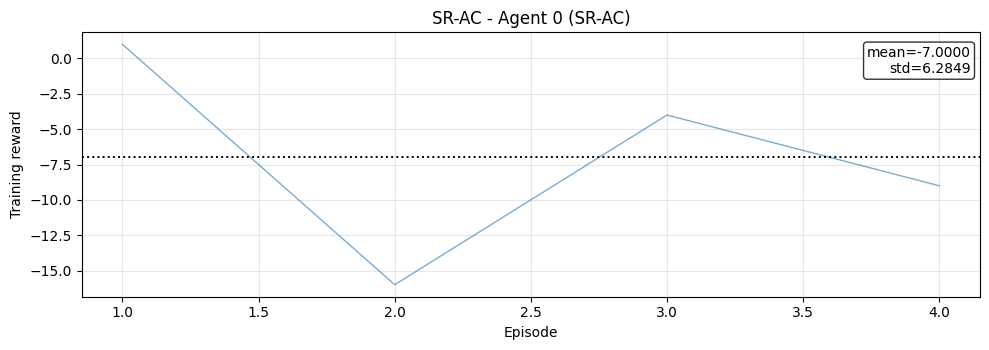

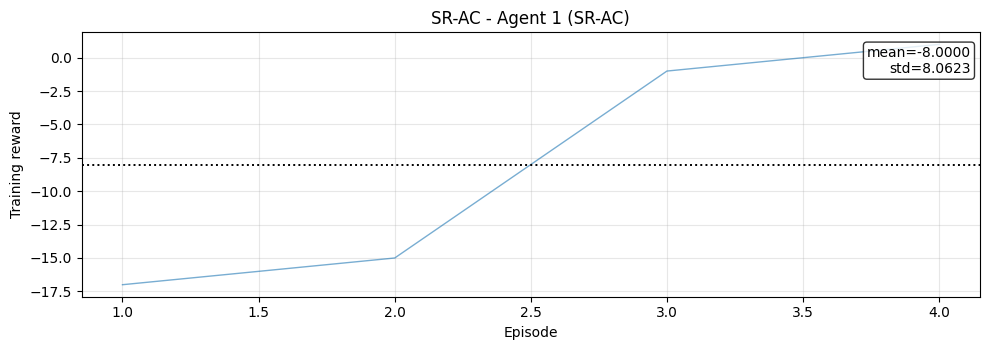

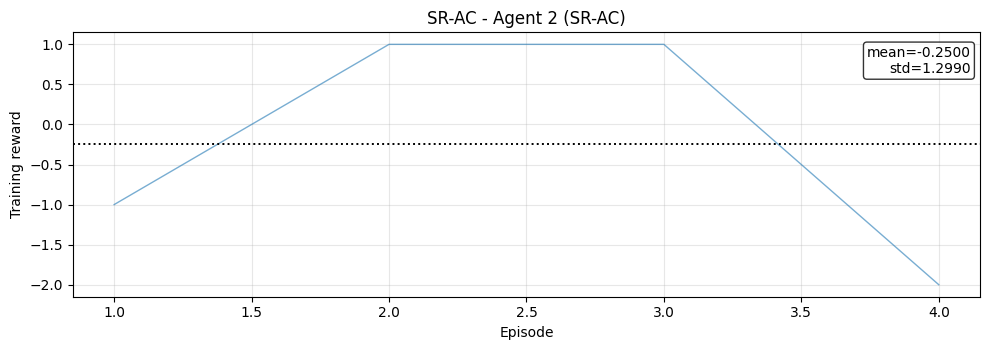

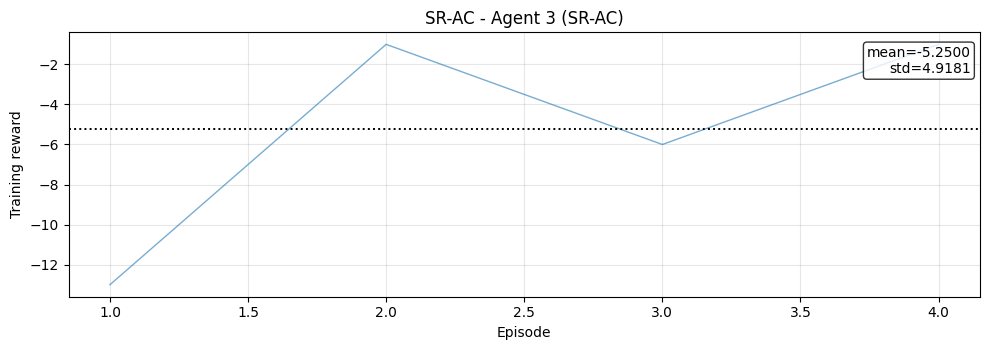

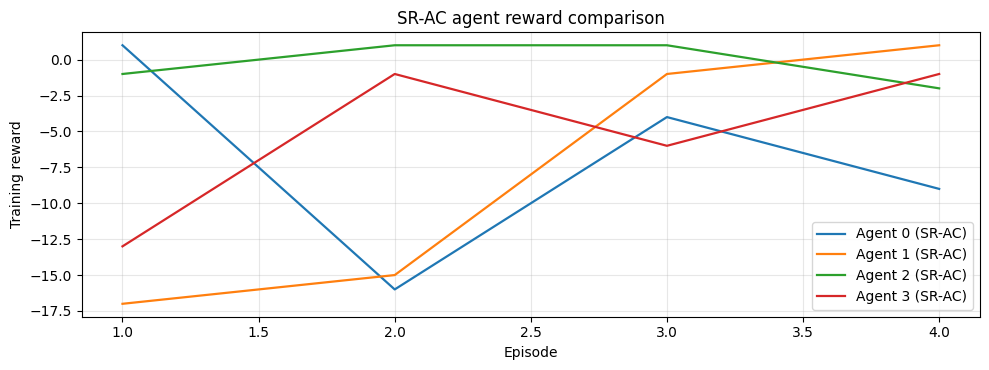

epsilon=0.01 schedule=constant decay_rate=0.995 artifact_dir=/home/wowthecoder/SRE-DQN/discrete_action_space/pommerman_ffa/srac/training/0.01/constant


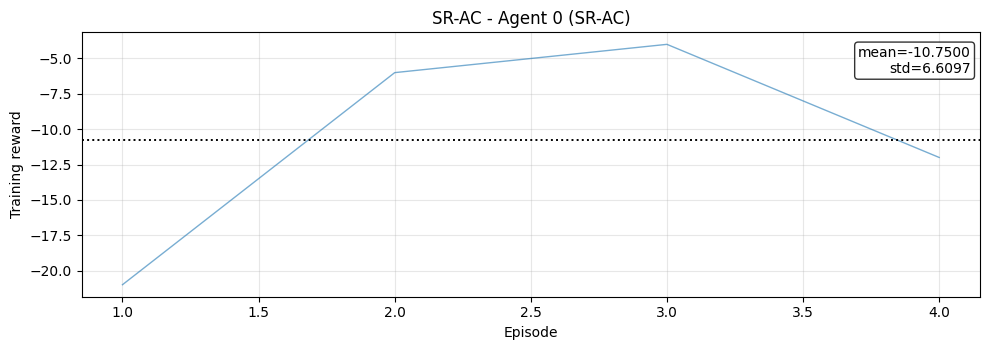

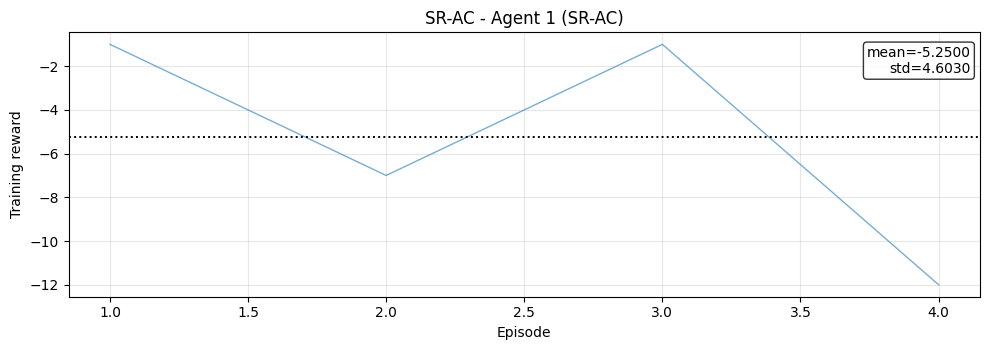

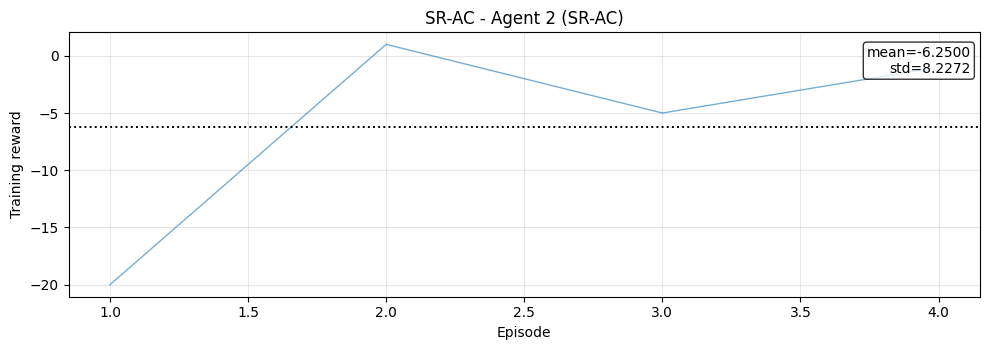

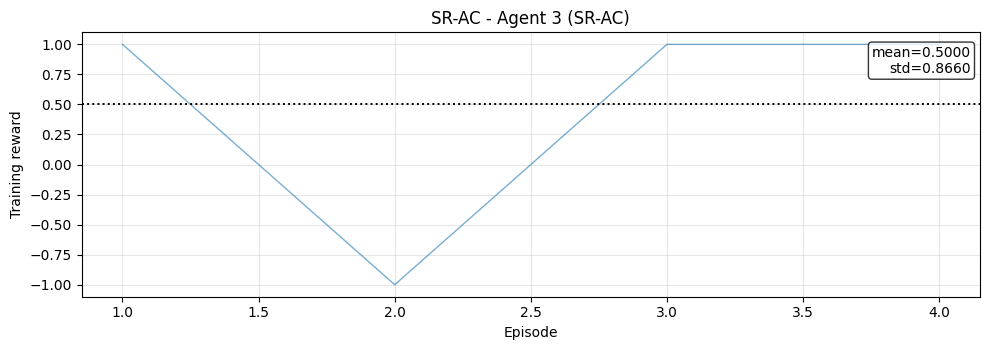

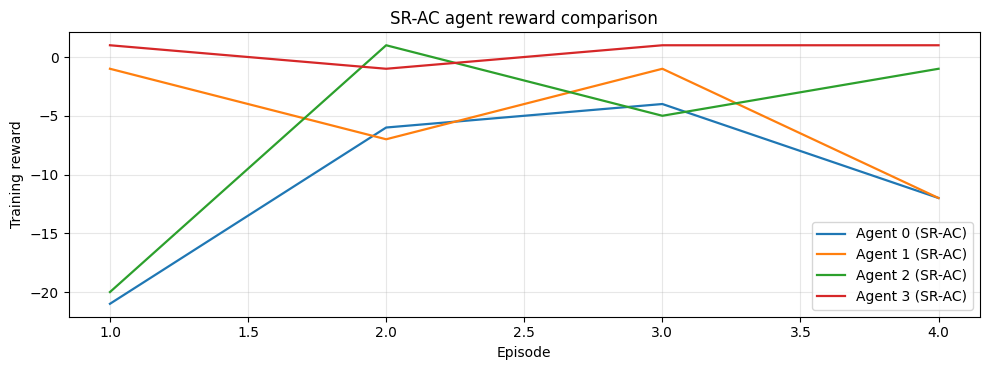

epsilon=0.01 schedule=exponential decay_rate=0.995 artifact_dir=/home/wowthecoder/SRE-DQN/discrete_action_space/pommerman_ffa/srac/training/0.01/exponential


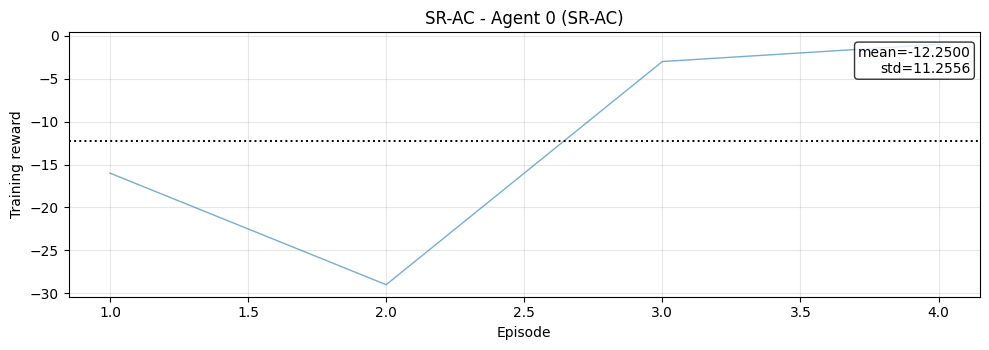

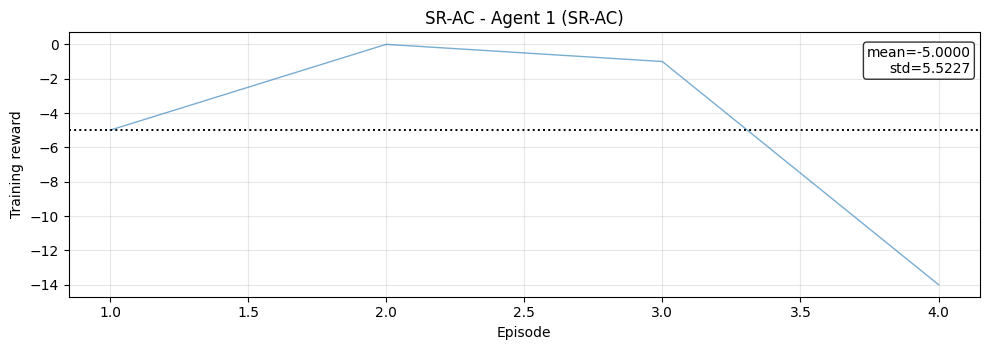

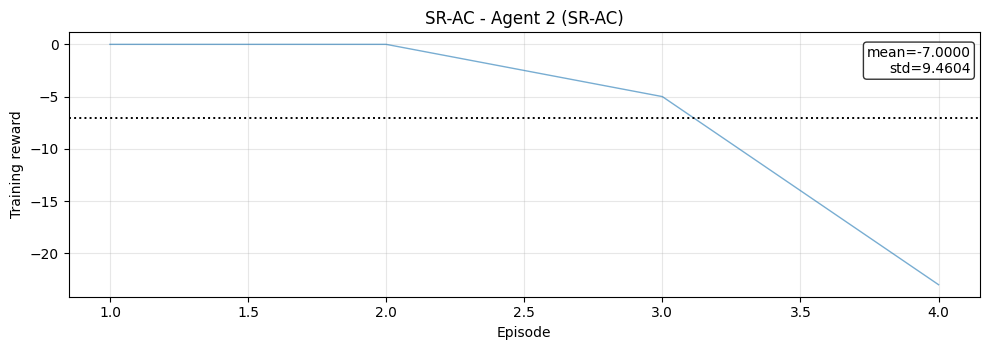

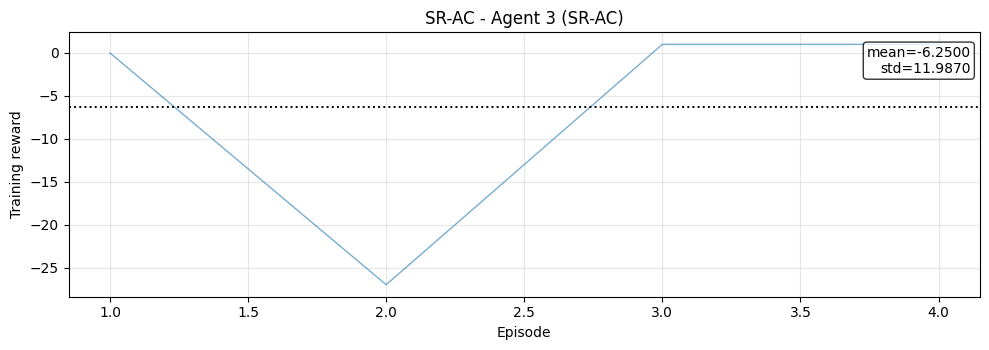

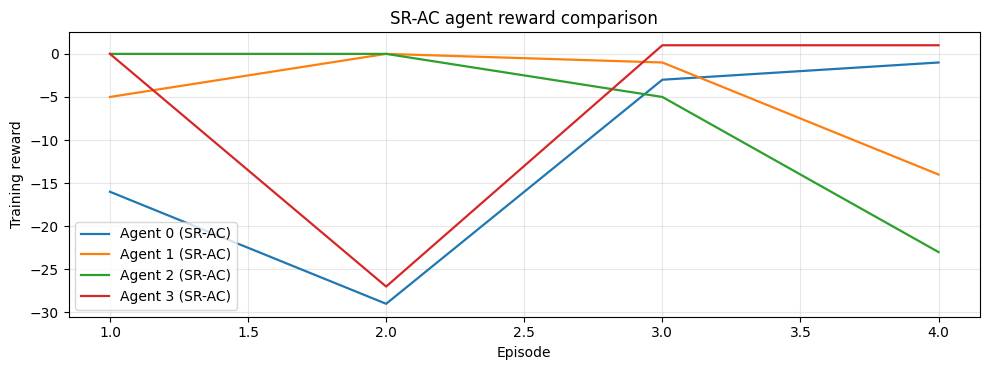

{'linear': {'environment': 'pommerman_ffa',
  'scenario_name': 'Pommerman FFA',
  'pair_label': 'SR-AC self-play',
  'pair_slug': 'sr_ac',
  'algorithm': 'SR-AC',
  'rewards': [[1.0, -16.0, -4.0, -9.0],
   [-17.0, -15.0, -1.0, 1.0],
   [-1.0, 1.0, 1.0, -2.0],
   [-13.0, -1.0, -6.0, -1.0]],
  'n_episodes': 4,
  'seed': 2026,
  'num_agents': 4,
  'num_actions': 6,
  'episode_lengths': [30, 25, 19, 23],
  'agent_labels': ['Agent 0 (SR-AC)',
   'Agent 1 (SR-AC)',
   'Agent 2 (SR-AC)',
   'Agent 3 (SR-AC)'],
  'artifact_dir': '/home/wowthecoder/SRE-DQN/discrete_action_space/pommerman_ffa/srac/training/0.01/linear',
  'solver_name': 'path_tvc_mcp_nplayer_pool',
  'nfg_transformer_checkpoint_path': None,
  'nfg_transformer_fallback_enabled': False,
  'nfg_transformer_accept_exploitability_tol': None,
  'epsilon_robust_initial': 0.01,
  'epsilon_schedule': 'linear',
  'robust_decay_rate': 0.995,
  'gradient_steps': 9,
  'batch_size': 32,
  'learning_starts': 64,
  'train_every': 4,
  'actor_up

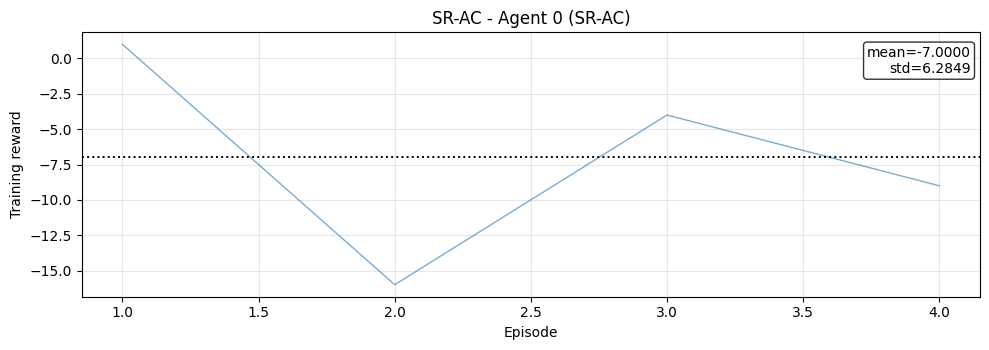

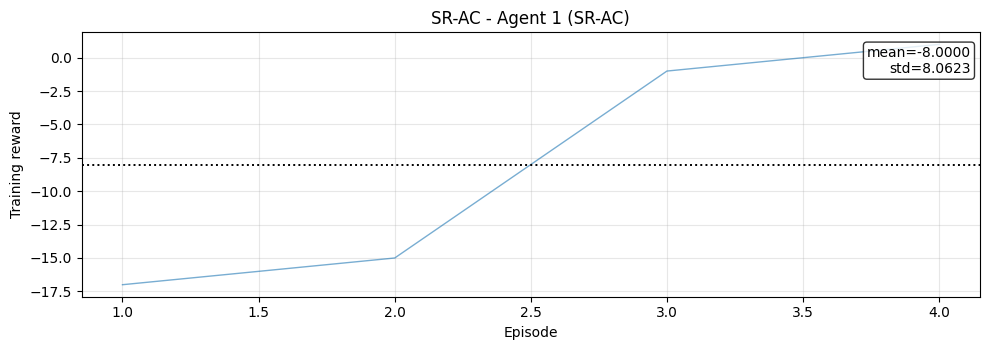

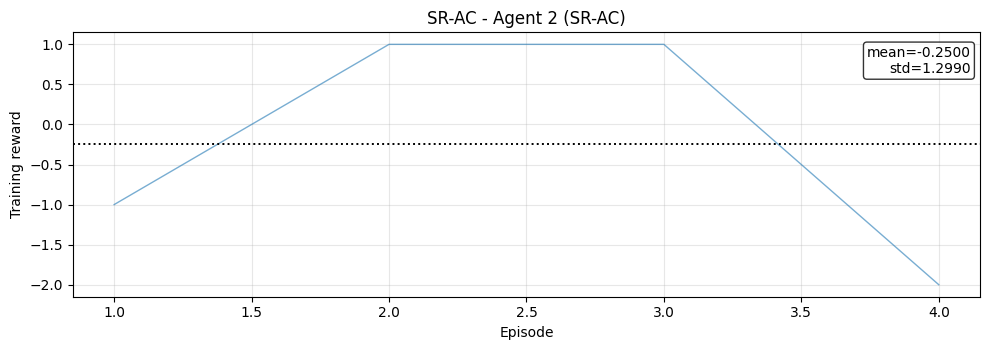

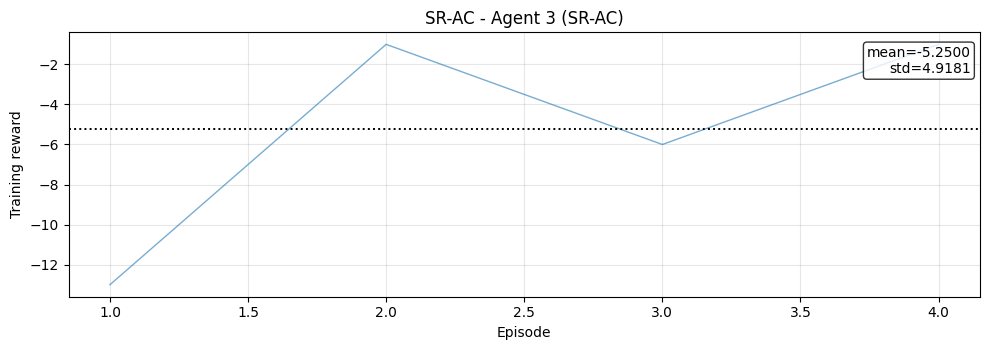

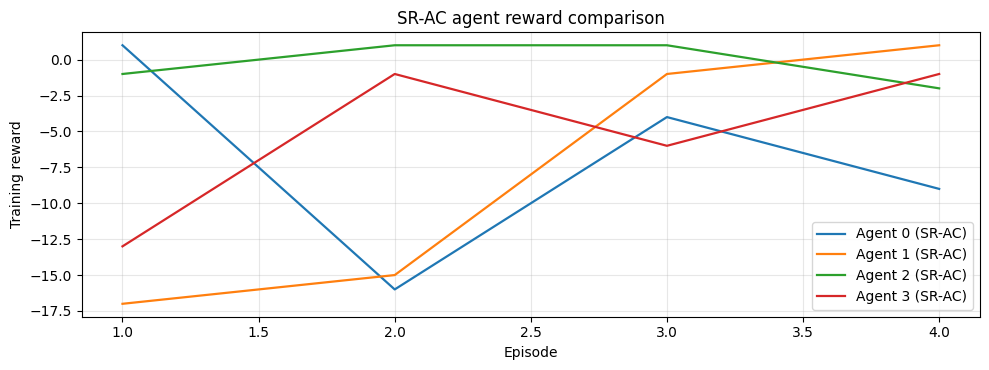

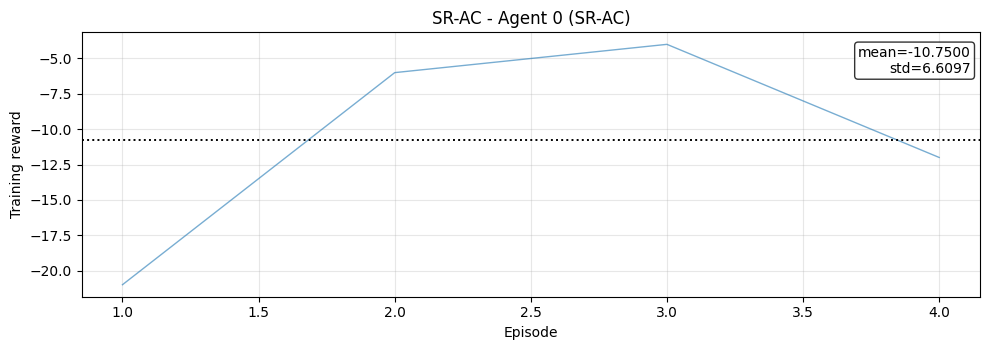

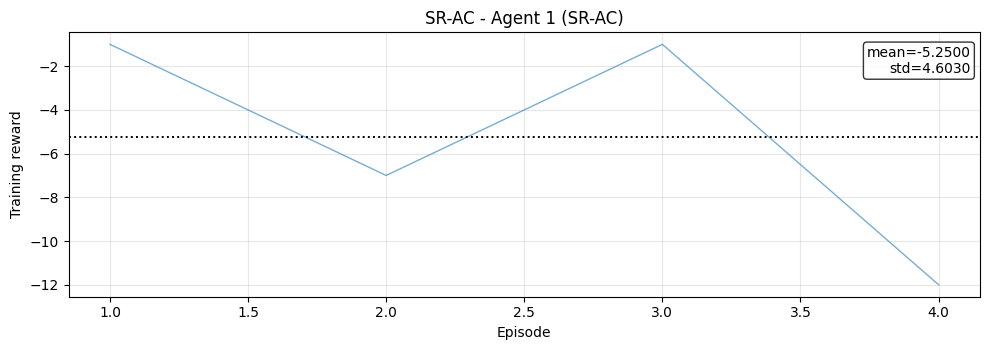

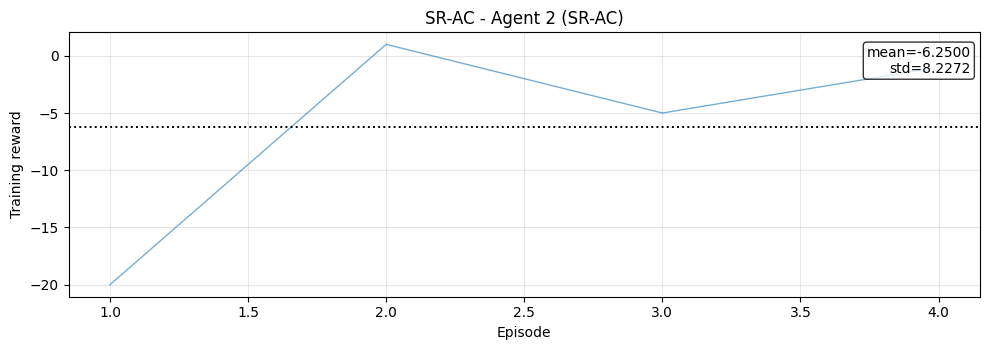

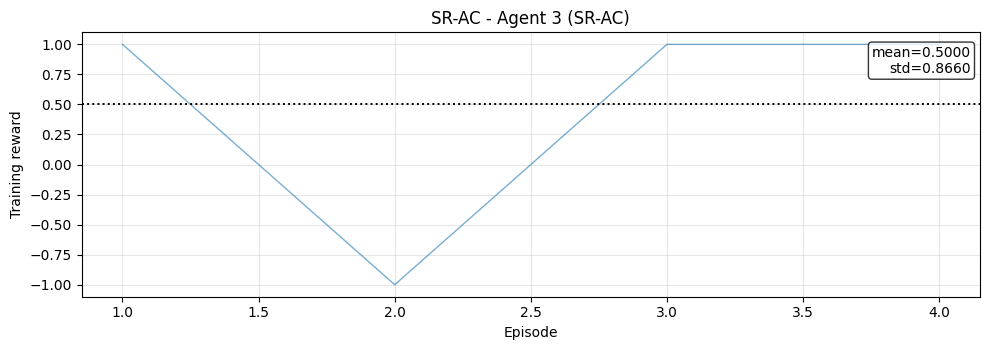

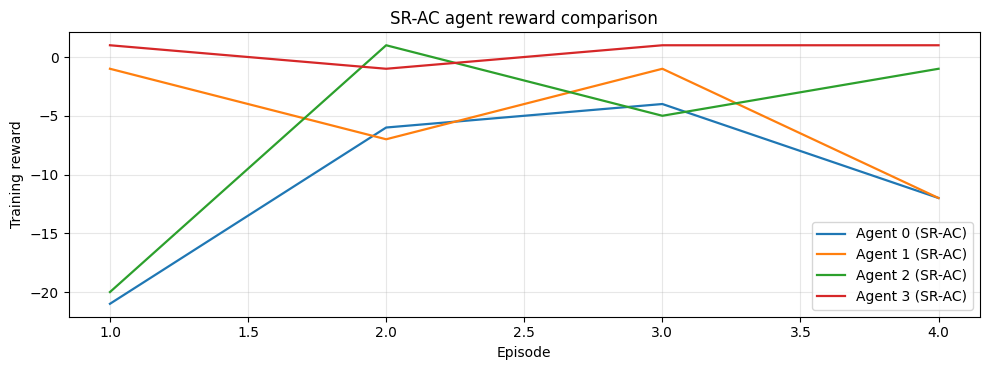

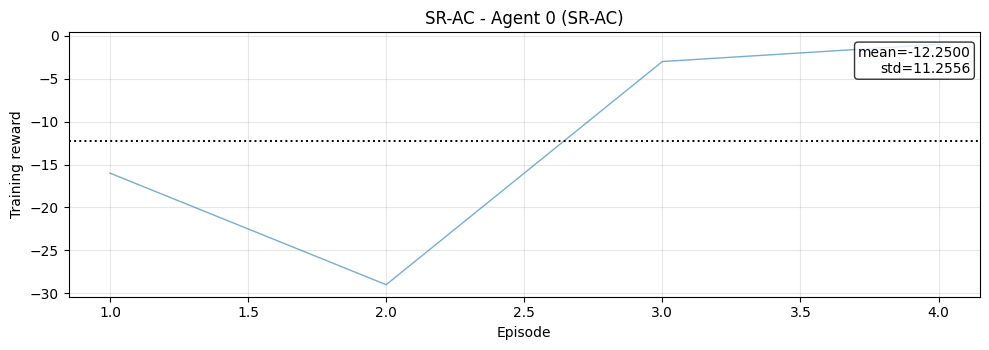

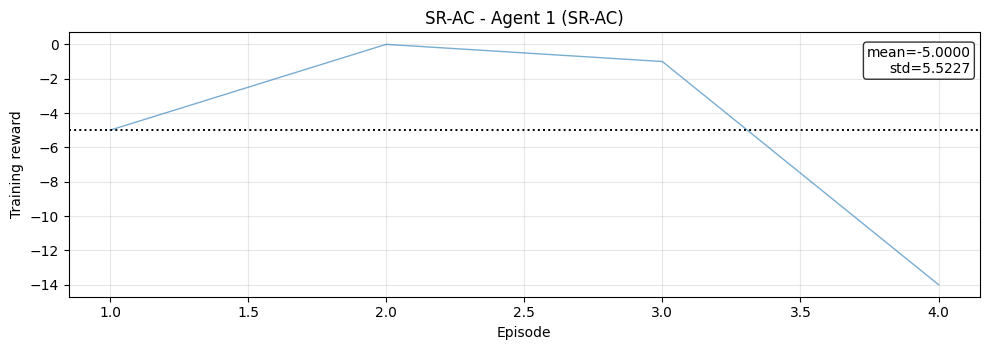

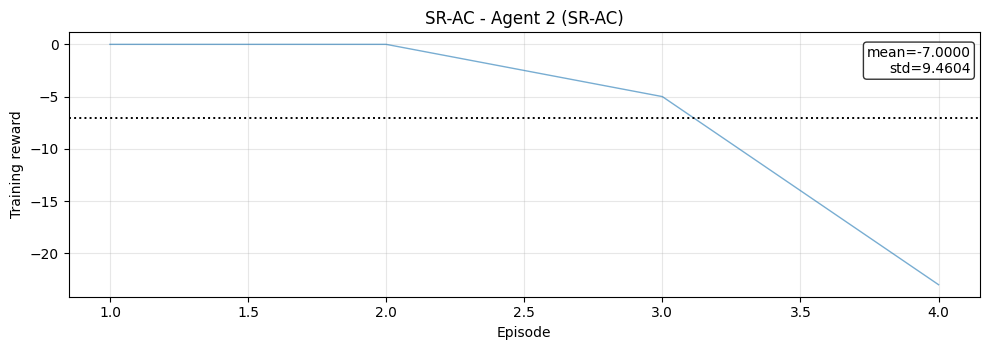

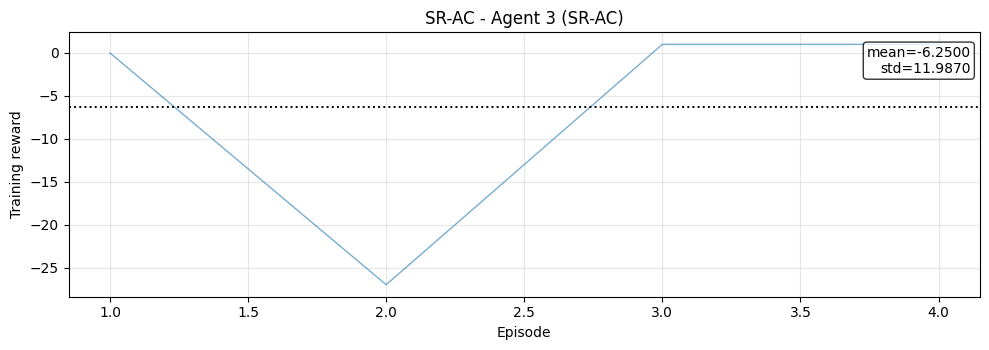

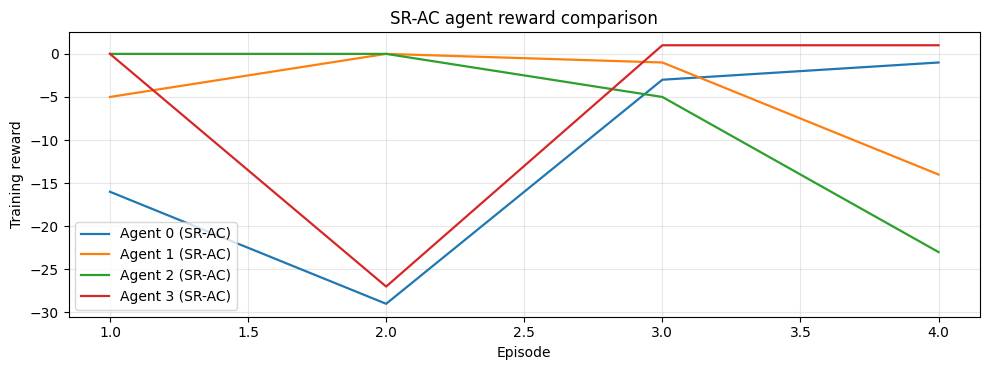

In [4]:
epsilon_0_01_stats = run_srac_schedule_sweep(0.01, seed_offset=1)
show_schedule_training_plots(0.01, epsilon_0_01_stats)

pommerman:srac: 100%|█████████████████████████████████████████████████████████████████████| 4/4 [00:05<00:00,  1.26s/it]


epsilon=0.1 schedule=linear decay_rate=0.995 artifact_dir=/home/wowthecoder/SRE-DQN/discrete_action_space/pommerman_ffa/srac/training/0.1/linear


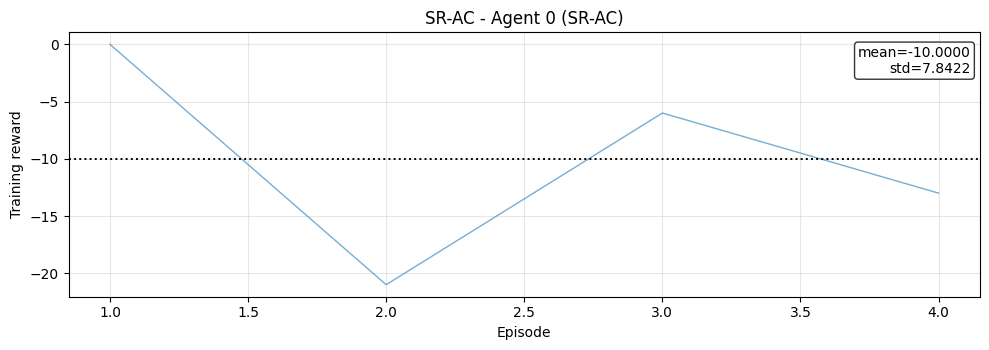

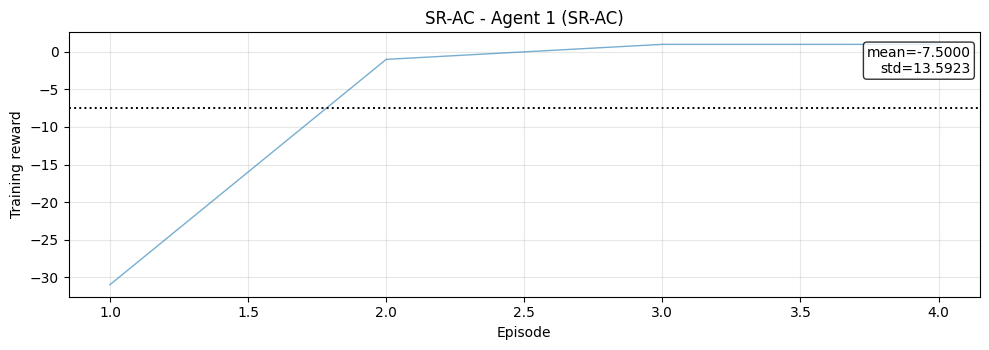

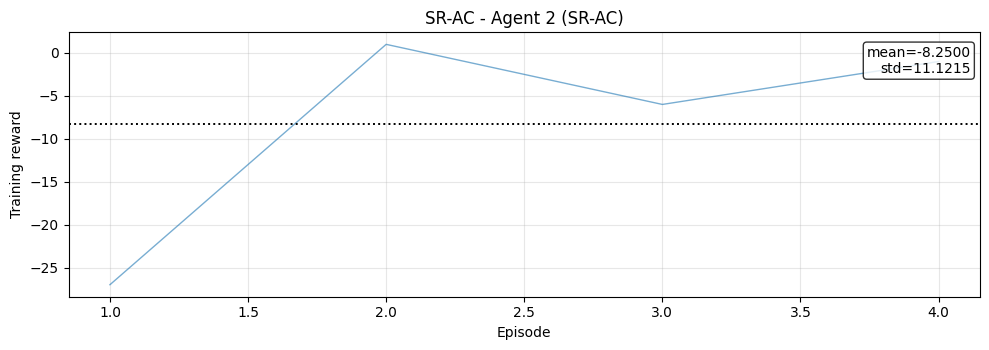

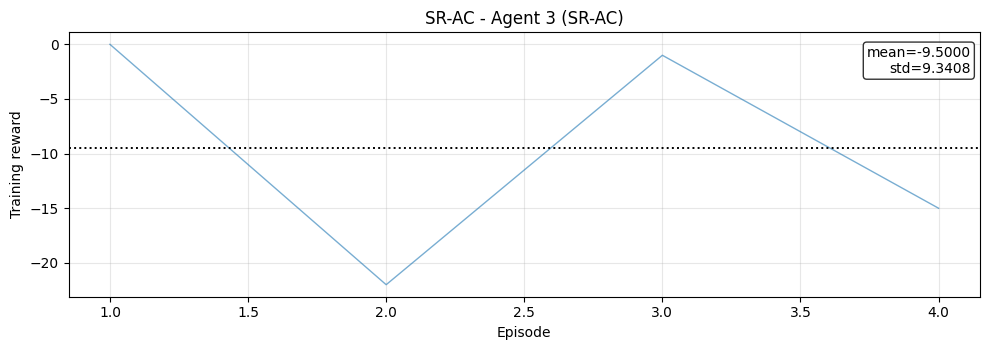

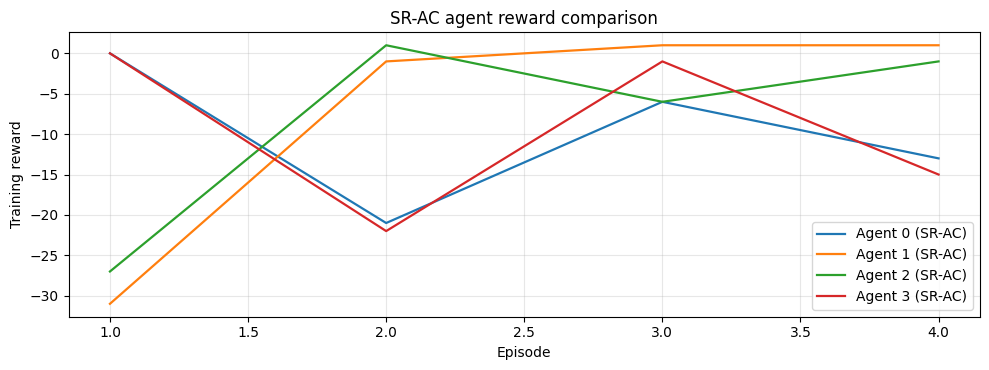

epsilon=0.1 schedule=constant decay_rate=0.995 artifact_dir=/home/wowthecoder/SRE-DQN/discrete_action_space/pommerman_ffa/srac/training/0.1/constant


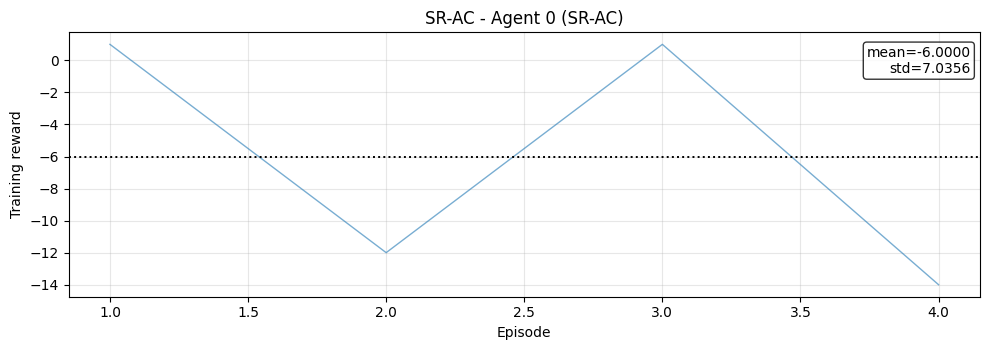

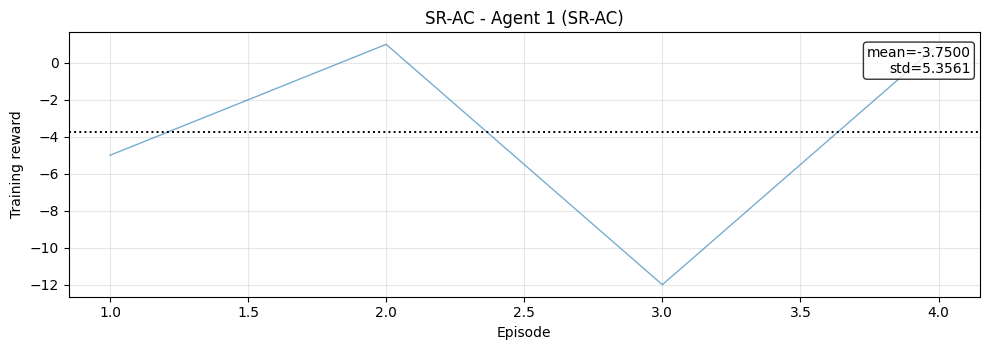

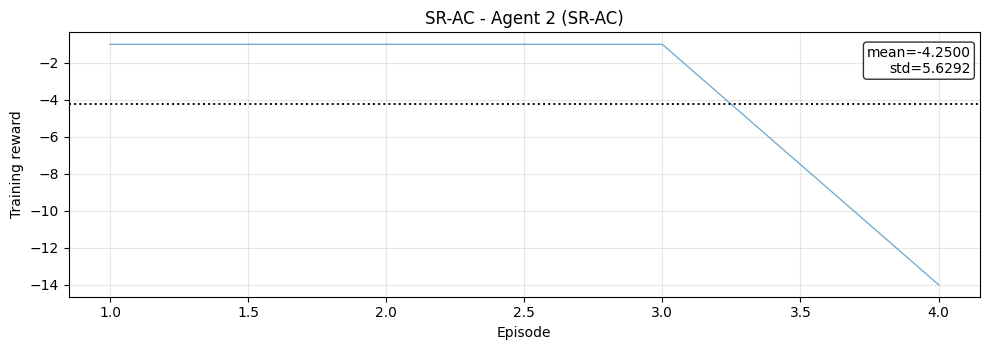

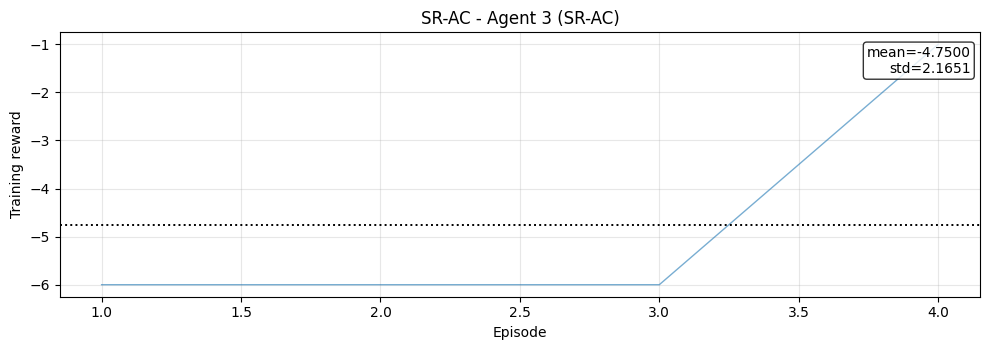

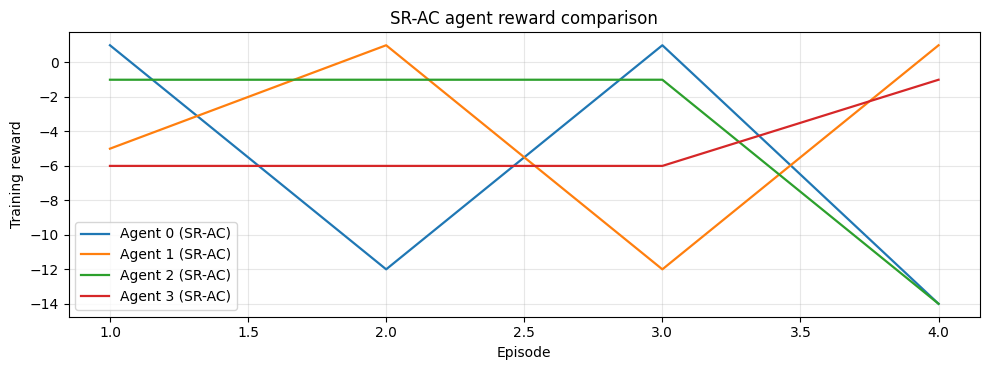

epsilon=0.1 schedule=exponential decay_rate=0.995 artifact_dir=/home/wowthecoder/SRE-DQN/discrete_action_space/pommerman_ffa/srac/training/0.1/exponential


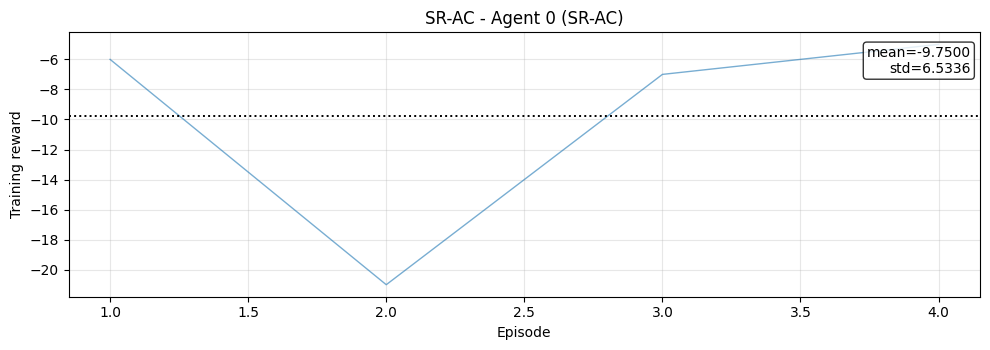

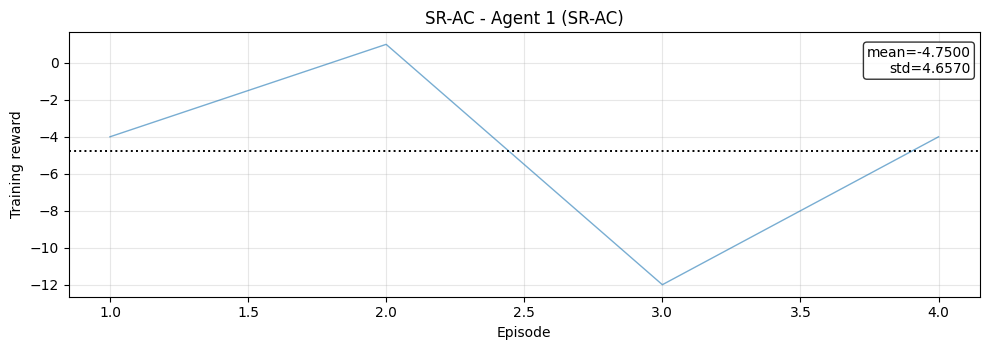

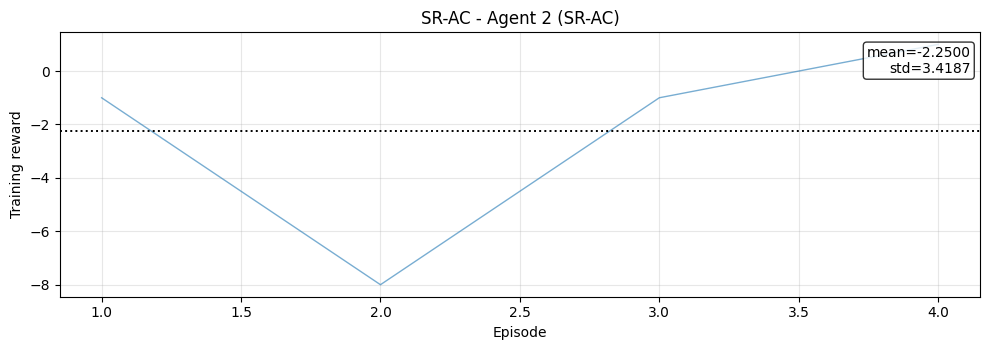

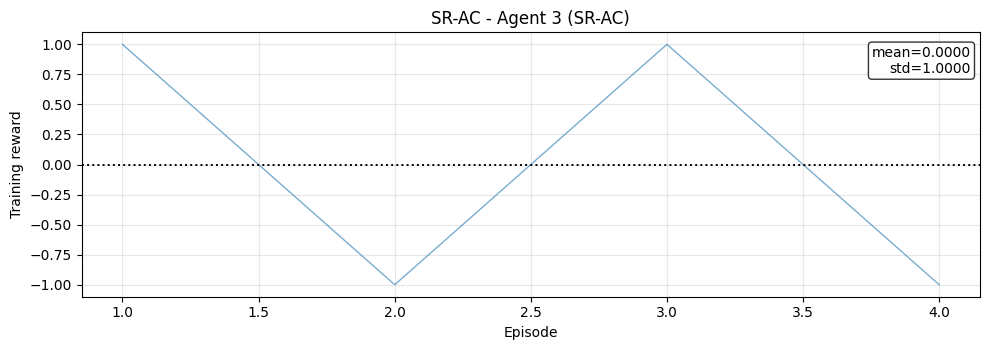

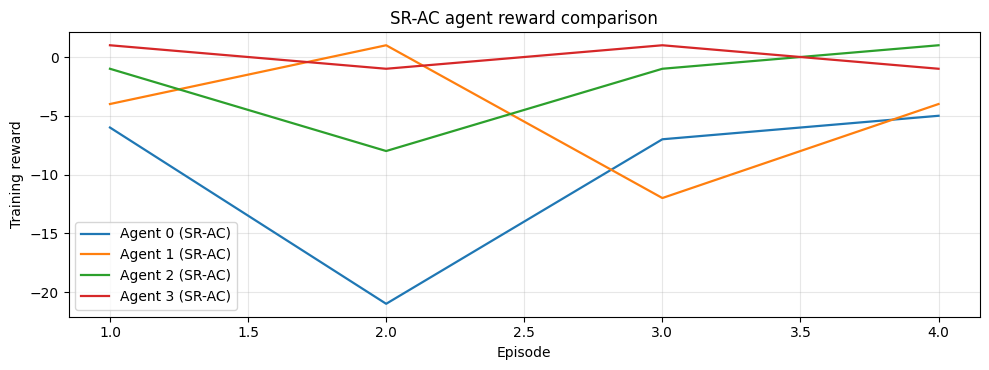

{'linear': {'environment': 'pommerman_ffa',
  'scenario_name': 'Pommerman FFA',
  'pair_label': 'SR-AC self-play',
  'pair_slug': 'sr_ac',
  'algorithm': 'SR-AC',
  'rewards': [[0.0, -21.0, -6.0, -13.0],
   [-31.0, -1.0, 1.0, 1.0],
   [-27.0, 1.0, -6.0, -1.0],
   [0.0, -22.0, -1.0, -15.0]],
  'n_episodes': 4,
  'seed': 2035,
  'num_agents': 4,
  'num_actions': 6,
  'episode_lengths': [40, 34, 16, 26],
  'agent_labels': ['Agent 0 (SR-AC)',
   'Agent 1 (SR-AC)',
   'Agent 2 (SR-AC)',
   'Agent 3 (SR-AC)'],
  'artifact_dir': '/home/wowthecoder/SRE-DQN/discrete_action_space/pommerman_ffa/srac/training/0.1/linear',
  'solver_name': 'path_tvc_mcp_nplayer_pool',
  'nfg_transformer_checkpoint_path': None,
  'nfg_transformer_fallback_enabled': False,
  'nfg_transformer_accept_exploitability_tol': None,
  'epsilon_robust_initial': 0.1,
  'epsilon_schedule': 'linear',
  'robust_decay_rate': 0.995,
  'gradient_steps': 14,
  'batch_size': 32,
  'learning_starts': 64,
  'train_every': 4,
  'actor_up

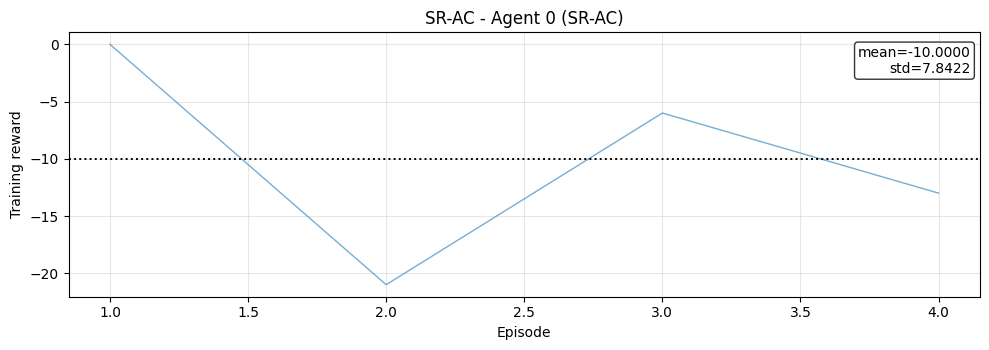

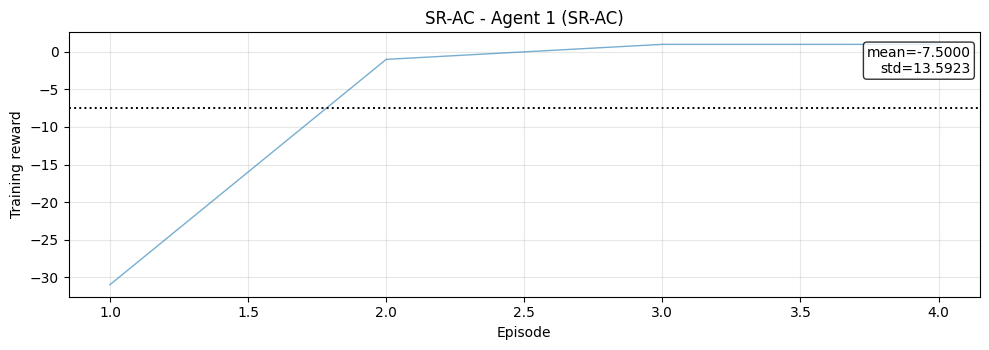

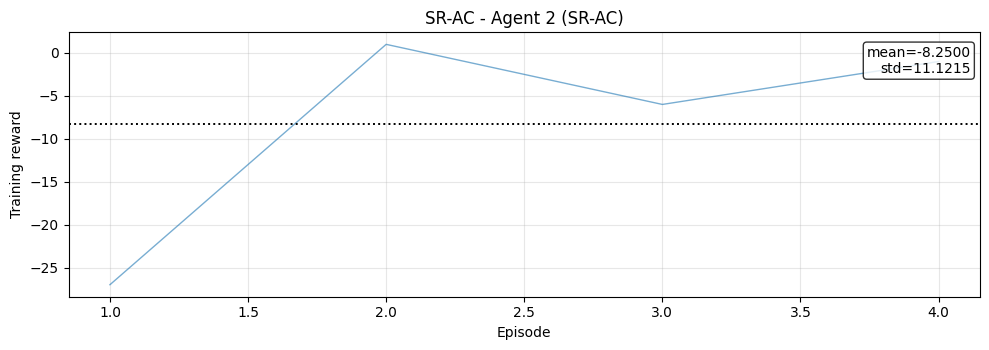

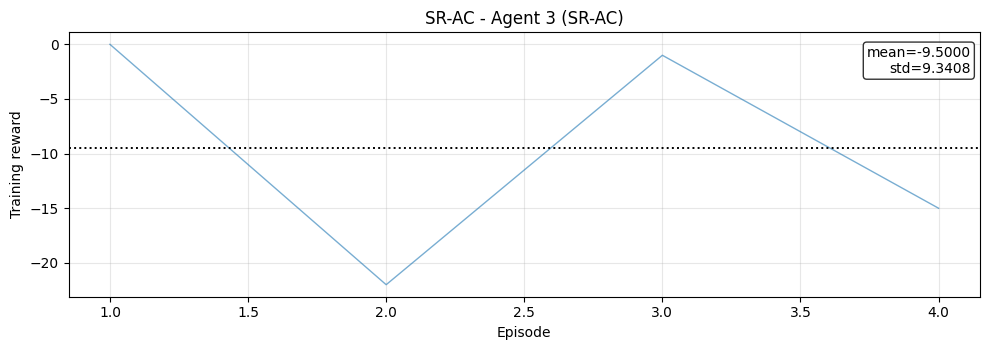

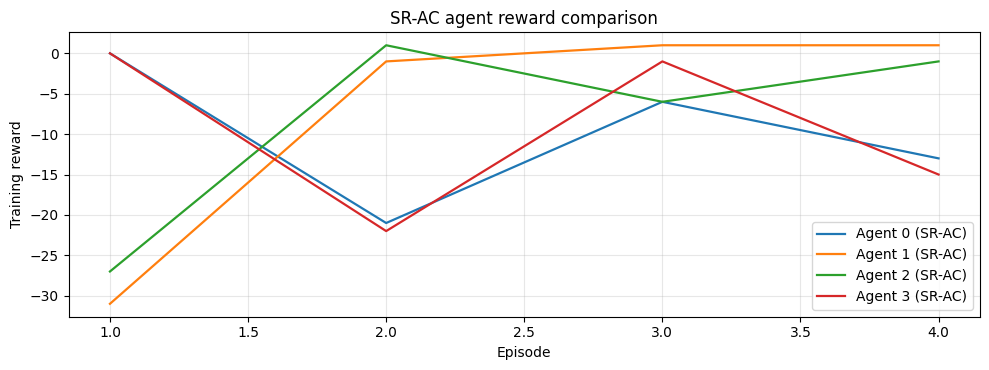

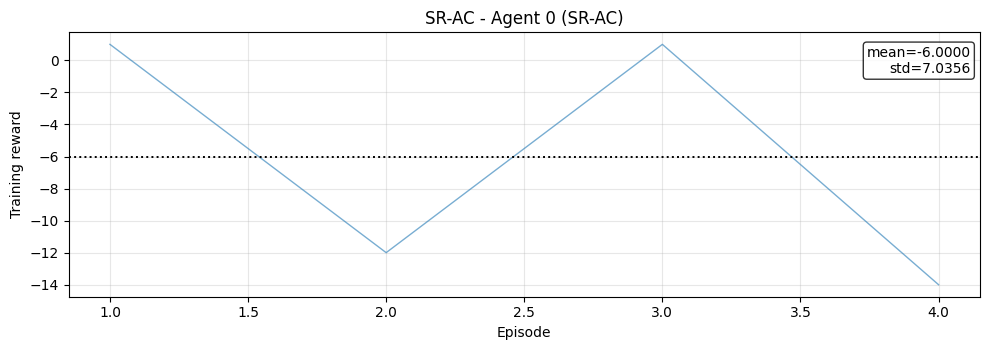

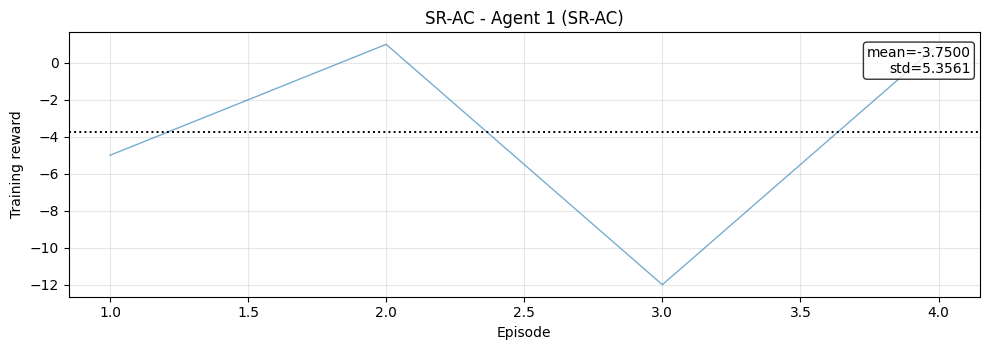

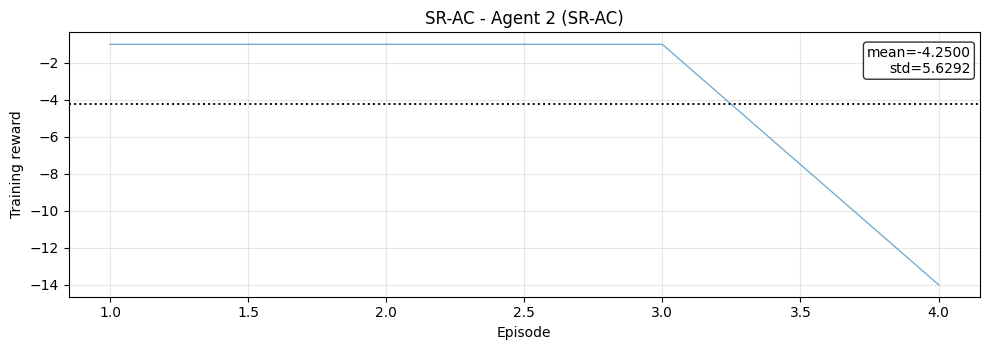

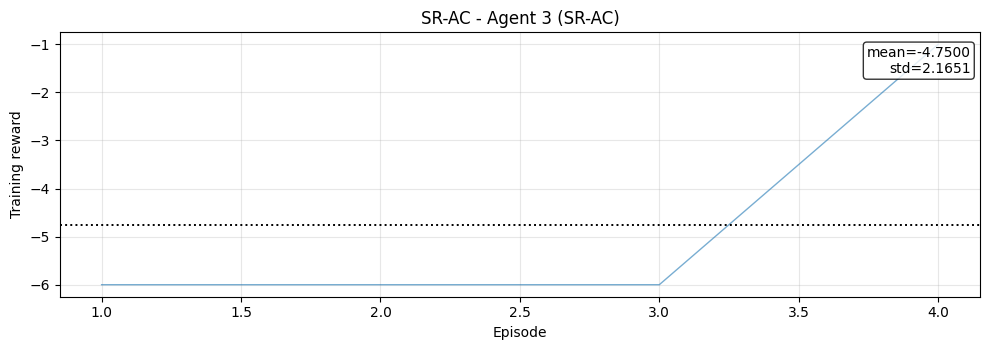

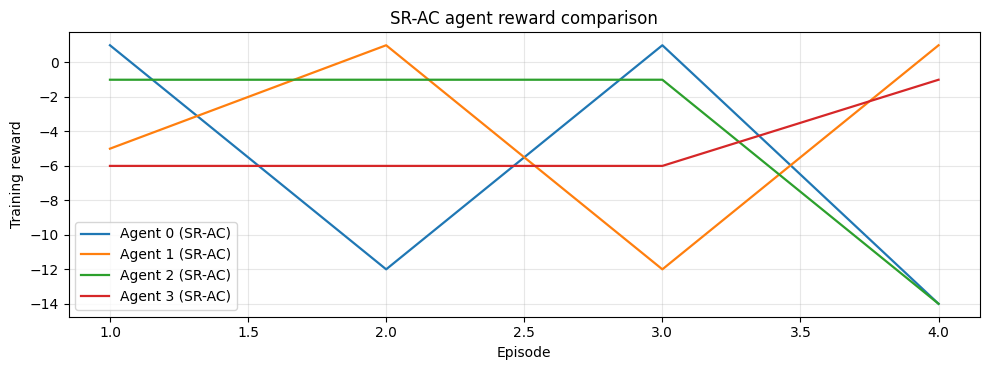

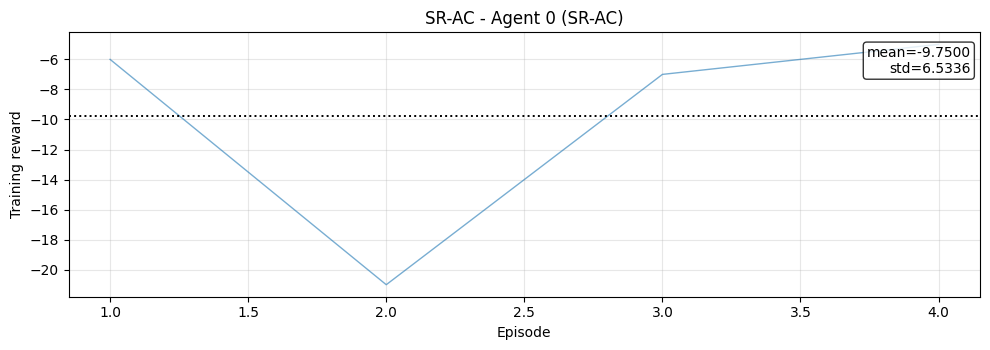

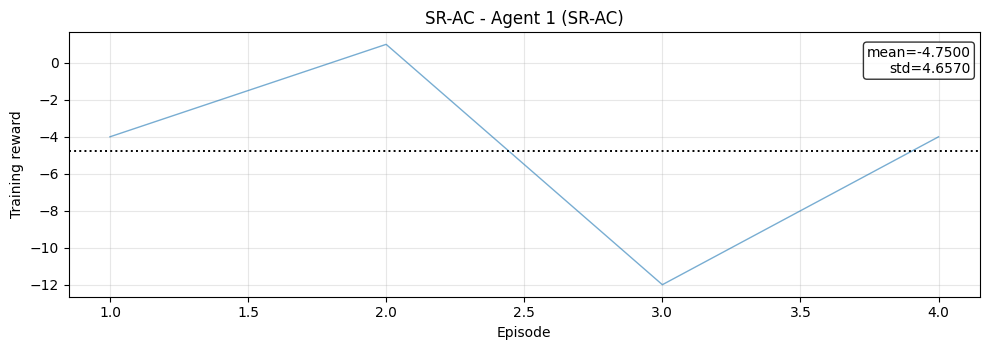

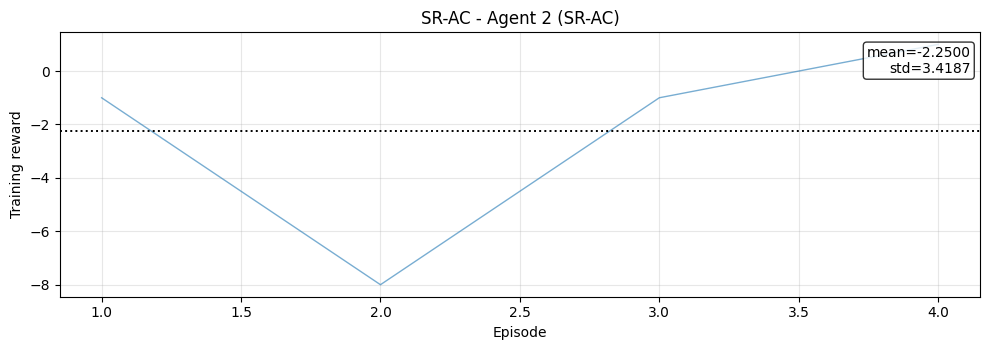

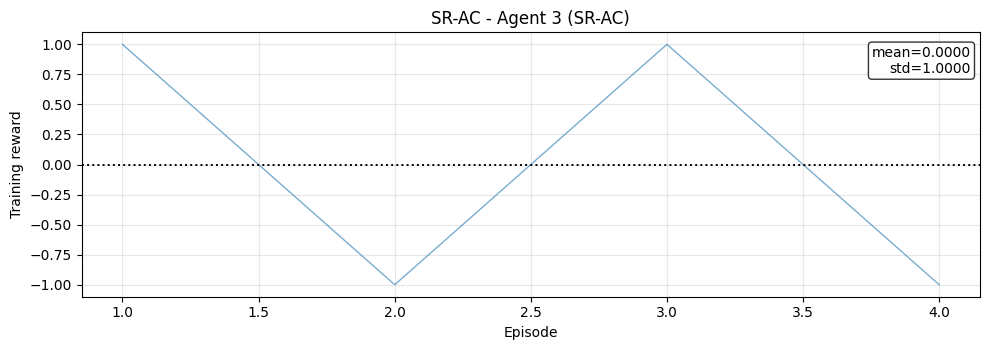

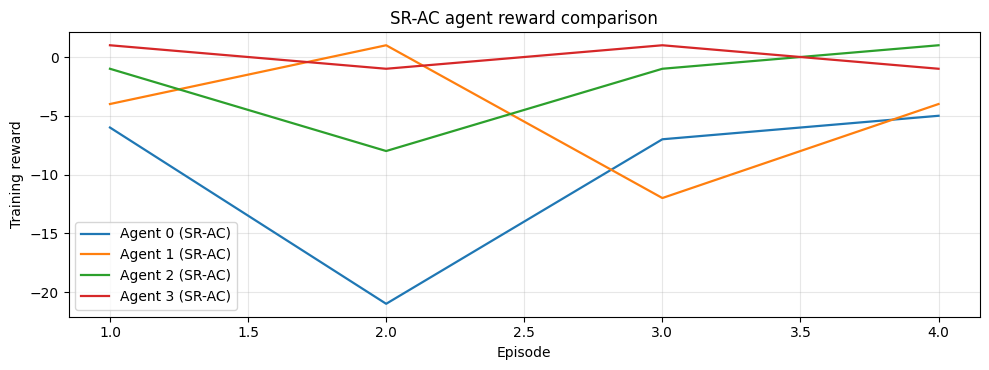

In [5]:
epsilon_0_1_stats = run_srac_schedule_sweep(0.1, seed_offset=10)
show_schedule_training_plots(0.1, epsilon_0_1_stats)
epsilon_0_1_stats

pommerman:srac: 100%|█████████████████████████████████████████████████████████████████████| 4/4 [00:05<00:00,  1.30s/it]


epsilon=0.5 schedule=linear decay_rate=0.995 artifact_dir=/home/wowthecoder/SRE-DQN/discrete_action_space/pommerman_ffa/srac/training/0.5/linear


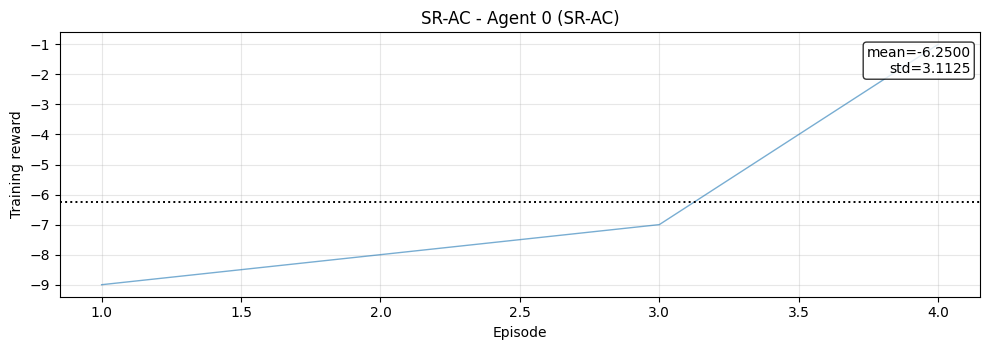

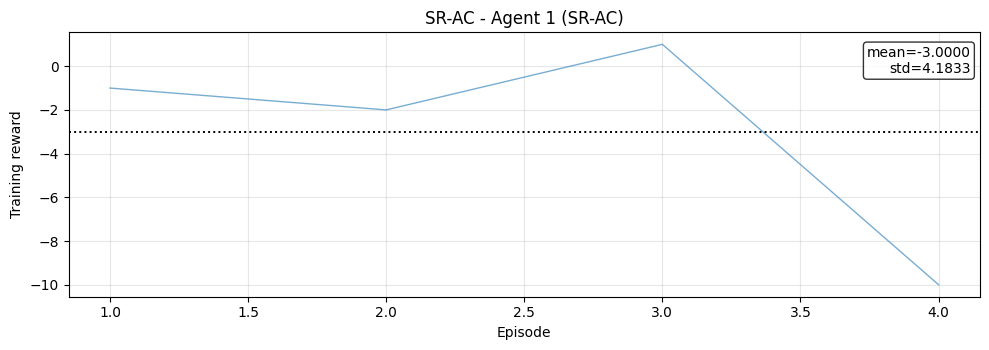

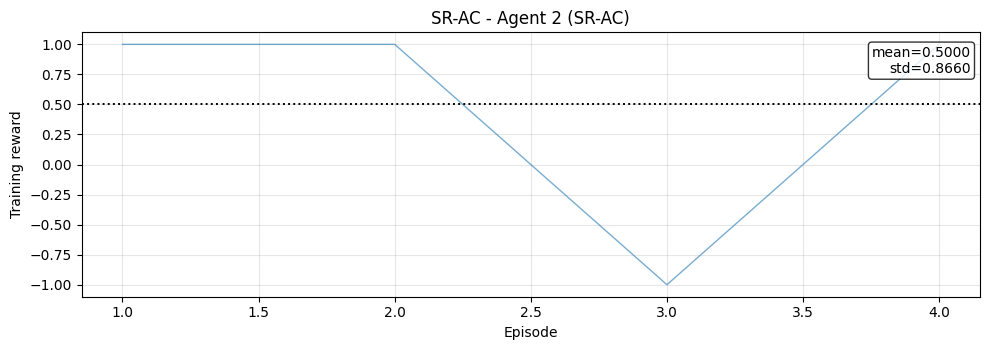

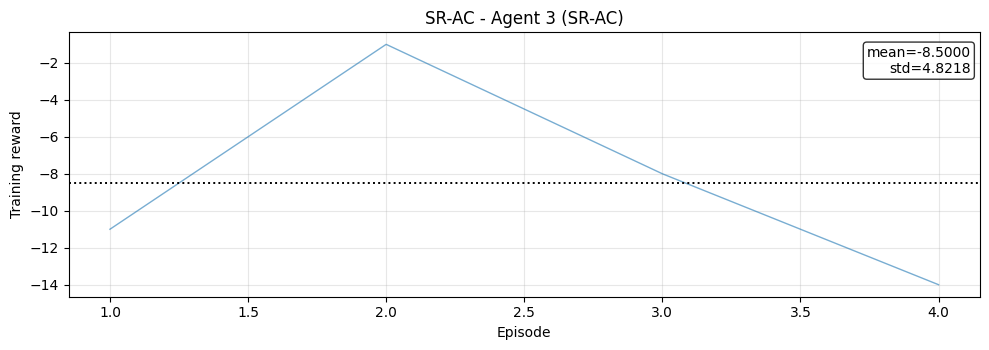

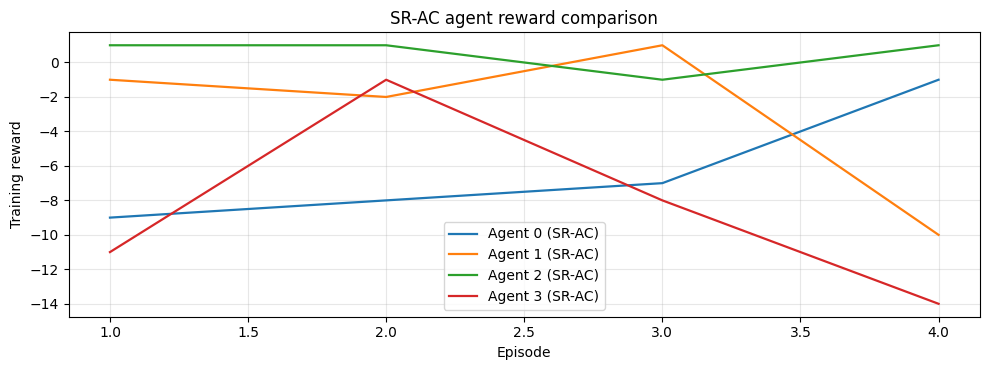

epsilon=0.5 schedule=constant decay_rate=0.995 artifact_dir=/home/wowthecoder/SRE-DQN/discrete_action_space/pommerman_ffa/srac/training/0.5/constant


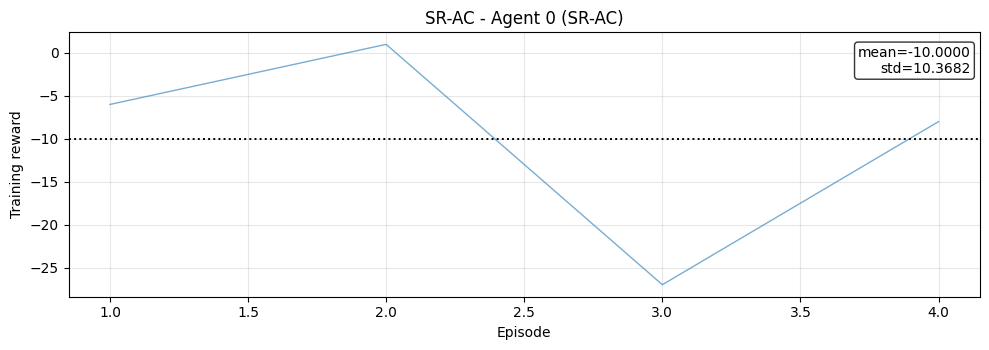

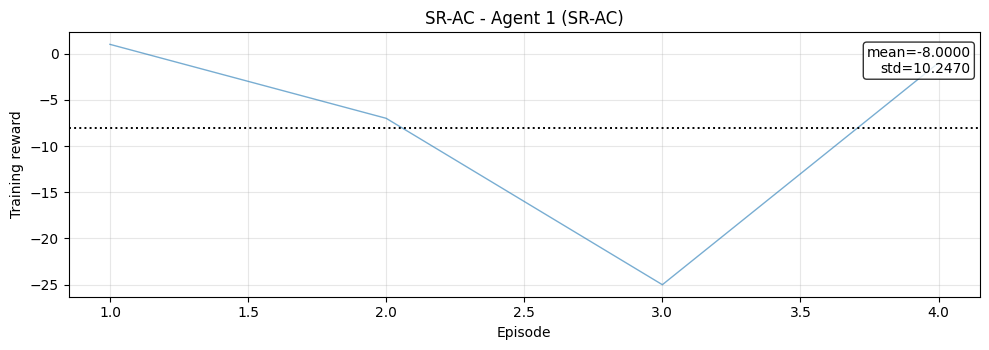

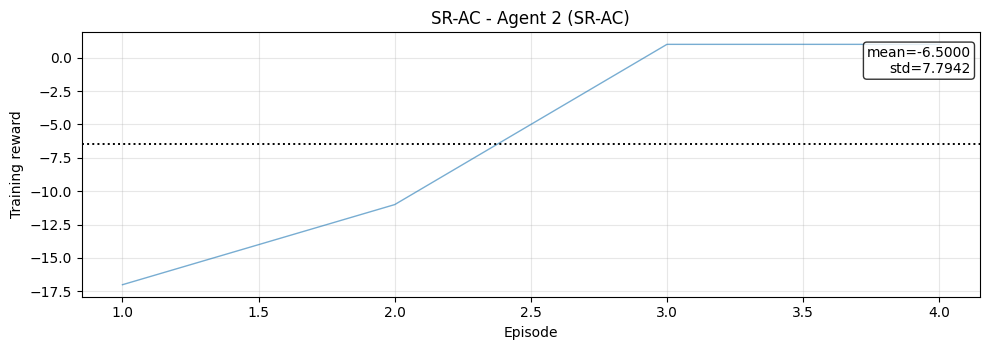

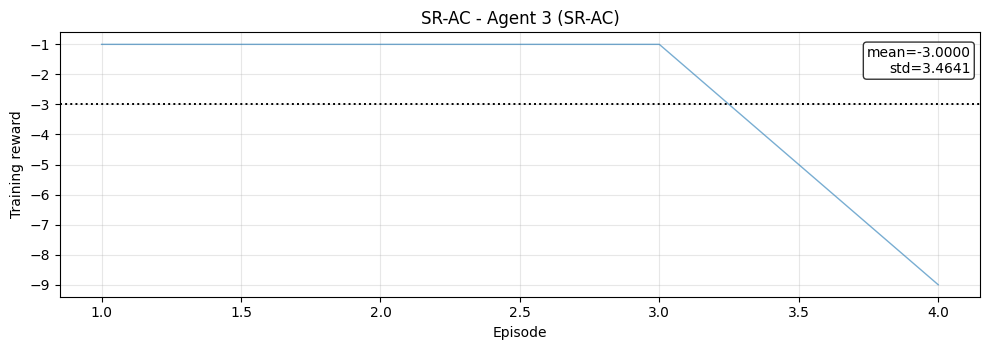

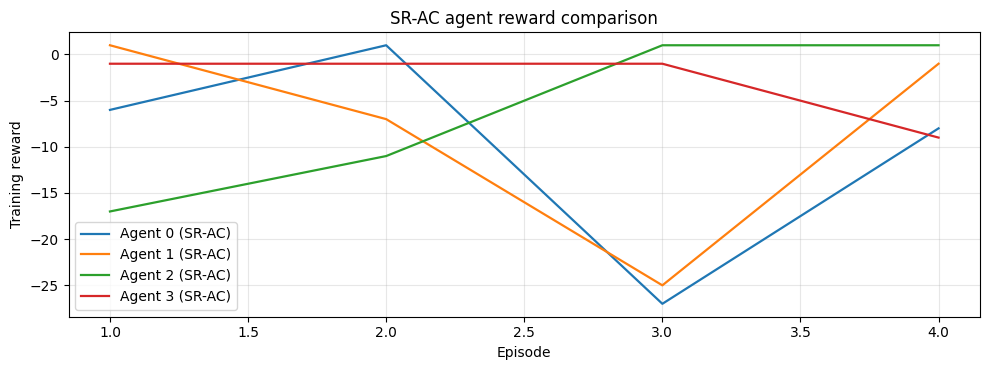

epsilon=0.5 schedule=exponential decay_rate=0.995 artifact_dir=/home/wowthecoder/SRE-DQN/discrete_action_space/pommerman_ffa/srac/training/0.5/exponential


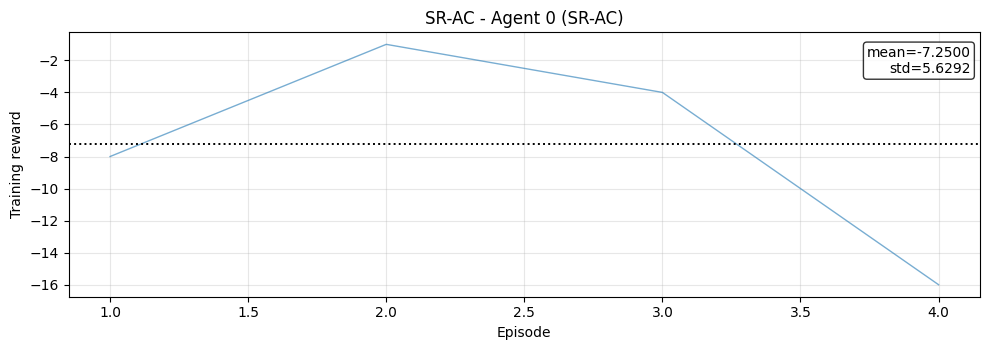

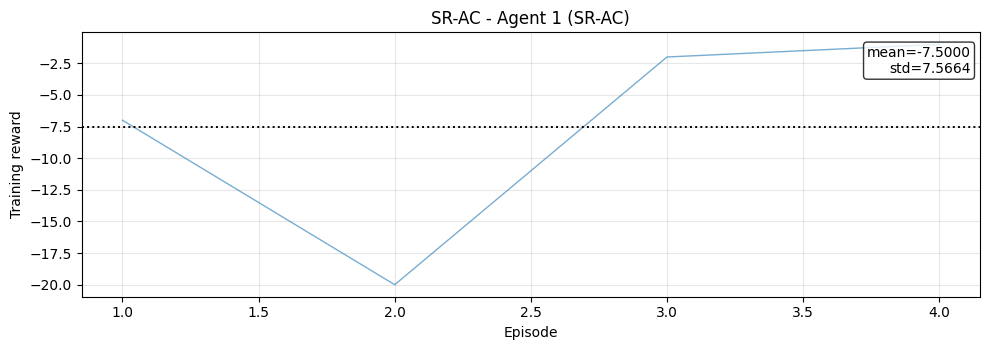

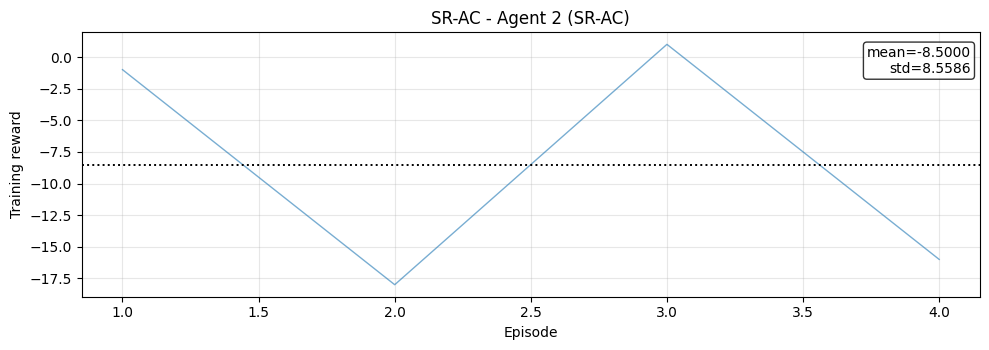

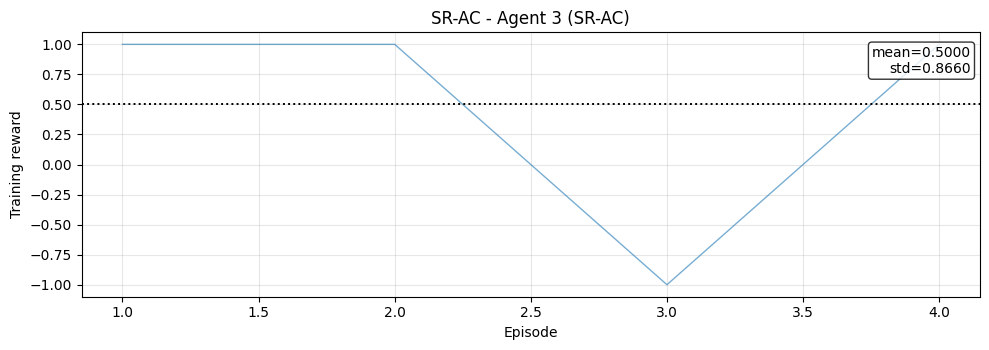

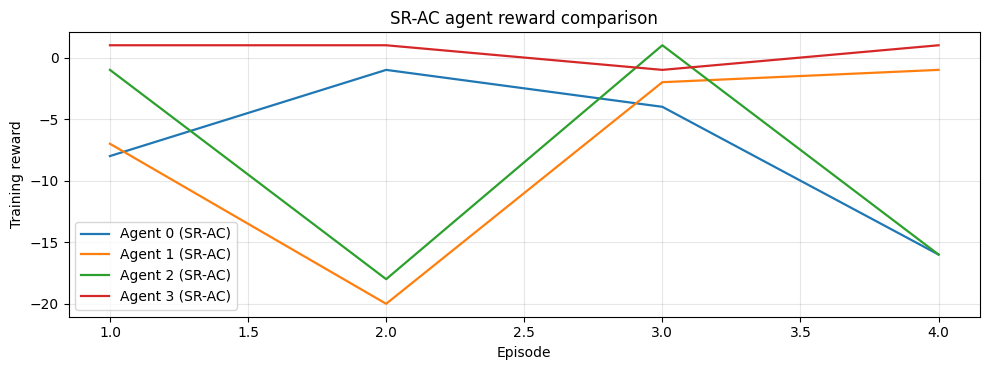

{'linear': {'environment': 'pommerman_ffa',
  'scenario_name': 'Pommerman FFA',
  'pair_label': 'SR-AC self-play',
  'pair_slug': 'sr_ac',
  'algorithm': 'SR-AC',
  'rewards': [[-9.0, -8.0, -7.0, -1.0],
   [-1.0, -2.0, 1.0, -10.0],
   [1.0, 1.0, -1.0, 1.0],
   [-11.0, -1.0, -8.0, -14.0]],
  'n_episodes': 4,
  'seed': 2075,
  'num_agents': 4,
  'num_actions': 6,
  'episode_lengths': [21, 18, 17, 24],
  'agent_labels': ['Agent 0 (SR-AC)',
   'Agent 1 (SR-AC)',
   'Agent 2 (SR-AC)',
   'Agent 3 (SR-AC)'],
  'artifact_dir': '/home/wowthecoder/SRE-DQN/discrete_action_space/pommerman_ffa/srac/training/0.5/linear',
  'solver_name': 'path_tvc_mcp_nplayer_pool',
  'nfg_transformer_checkpoint_path': None,
  'nfg_transformer_fallback_enabled': False,
  'nfg_transformer_accept_exploitability_tol': None,
  'epsilon_robust_initial': 0.5,
  'epsilon_schedule': 'linear',
  'robust_decay_rate': 0.995,
  'gradient_steps': 5,
  'batch_size': 32,
  'learning_starts': 64,
  'train_every': 4,
  'actor_updat

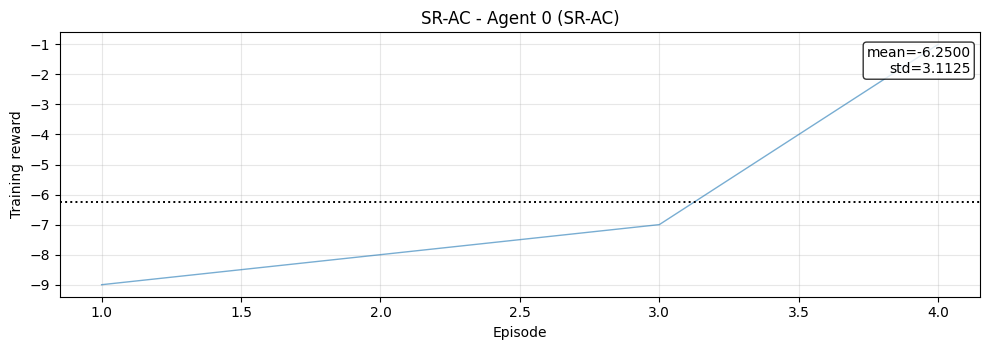

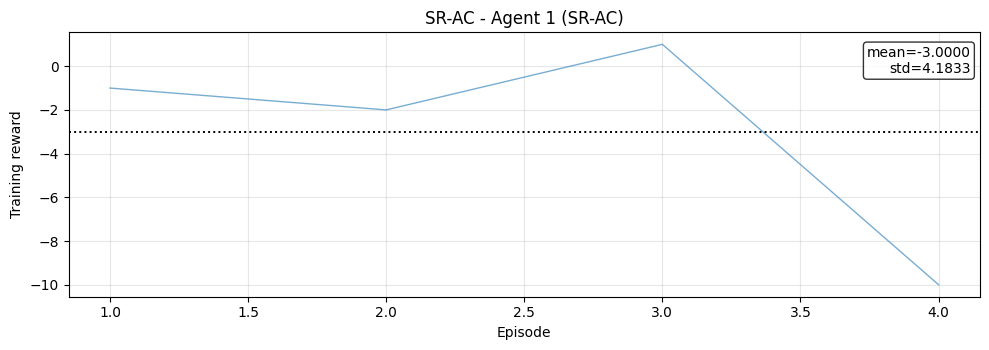

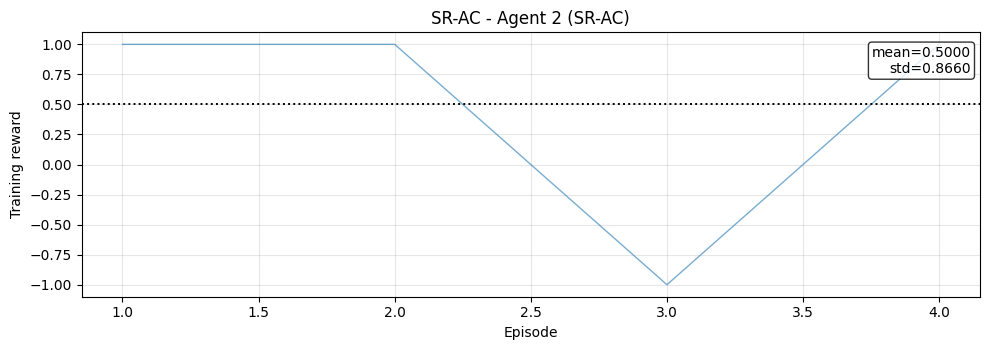

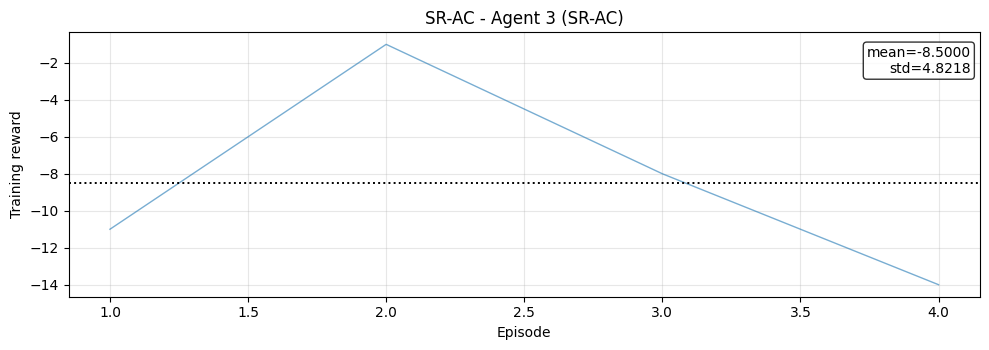

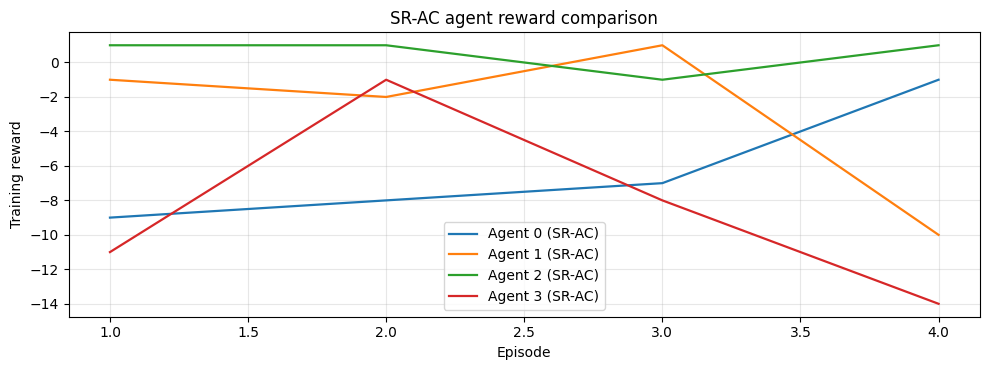

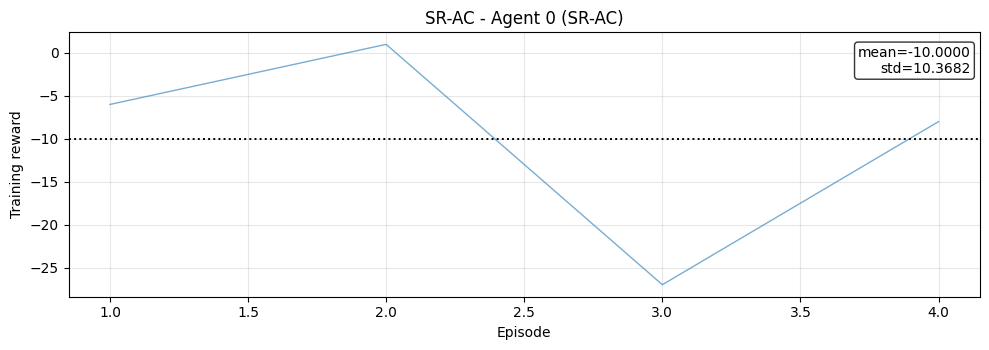

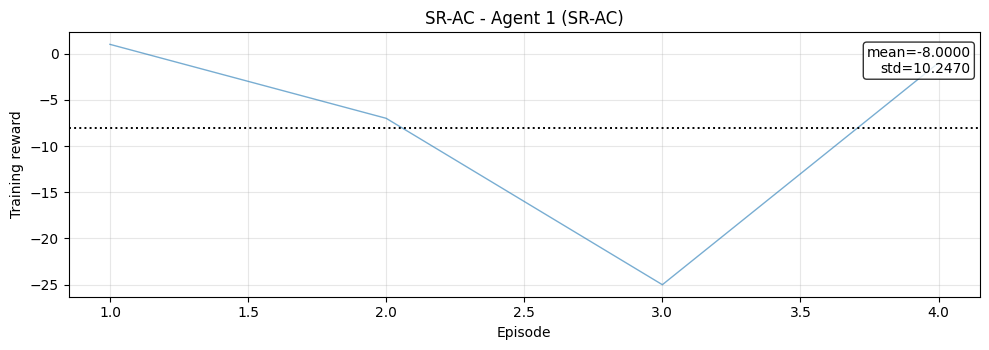

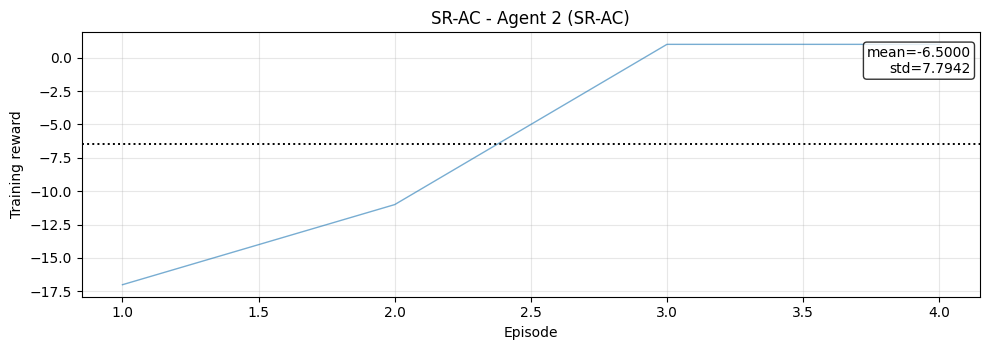

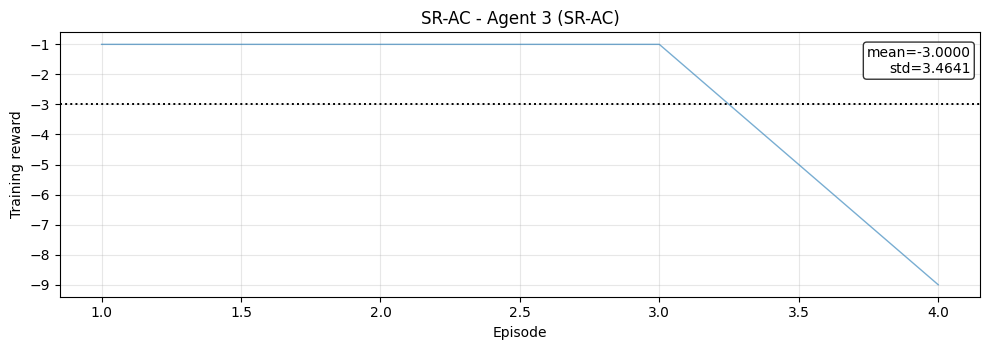

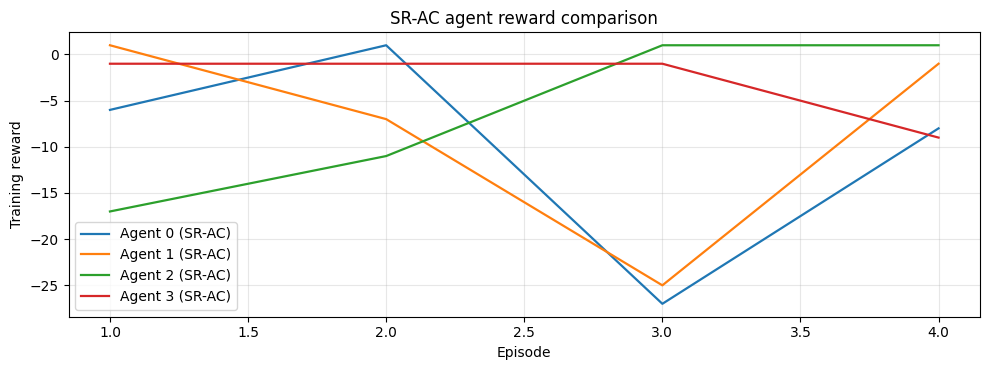

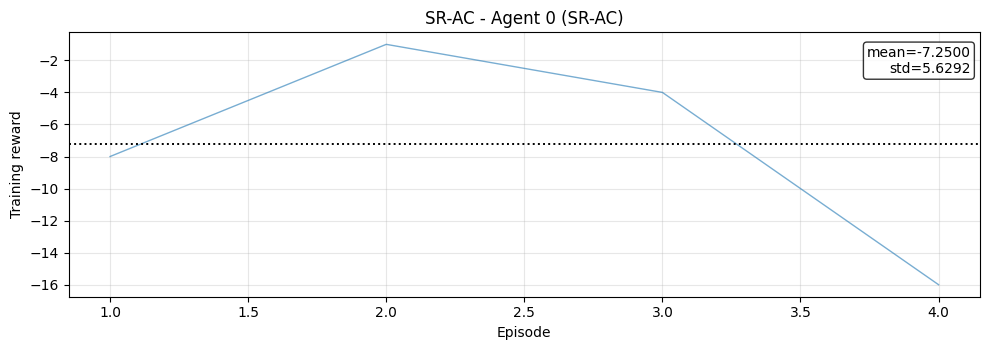

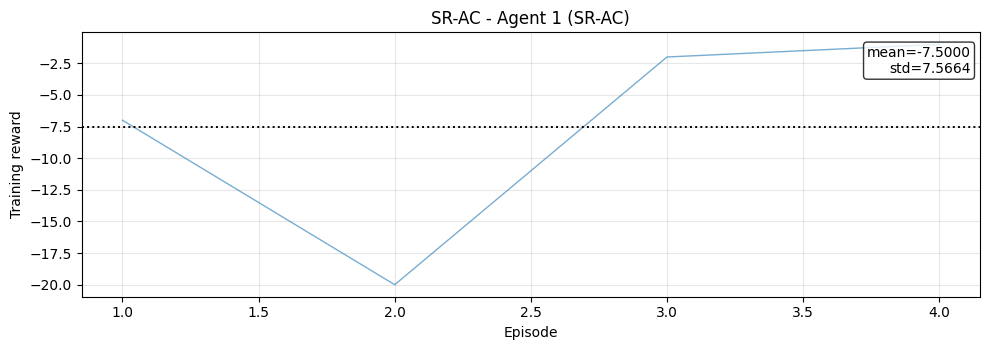

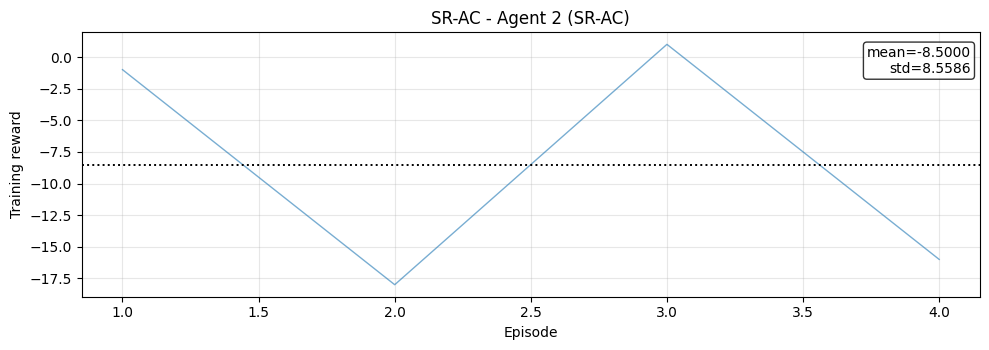

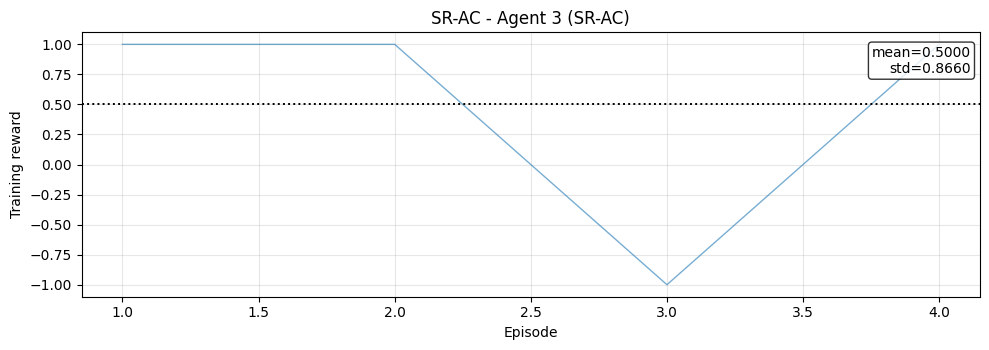

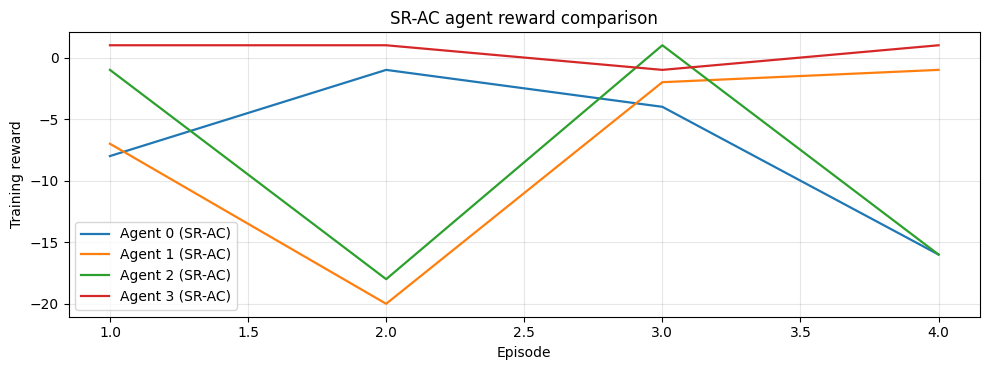

In [6]:
epsilon_0_5_stats = run_srac_schedule_sweep(0.5, seed_offset=50)
show_schedule_training_plots(0.5, epsilon_0_5_stats)

pommerman:srac: 100%|█████████████████████████████████████████████████████████████████████| 4/4 [00:07<00:00,  1.96s/it]


epsilon=1.0 schedule=linear decay_rate=0.995 artifact_dir=/home/wowthecoder/SRE-DQN/discrete_action_space/pommerman_ffa/srac/training/1.0/linear


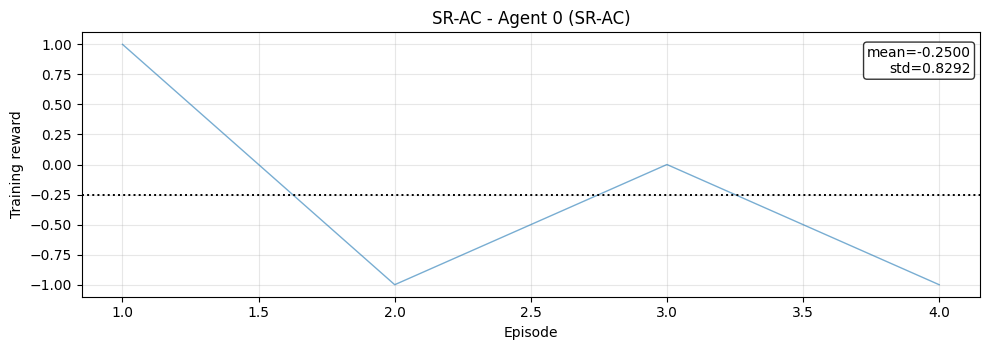

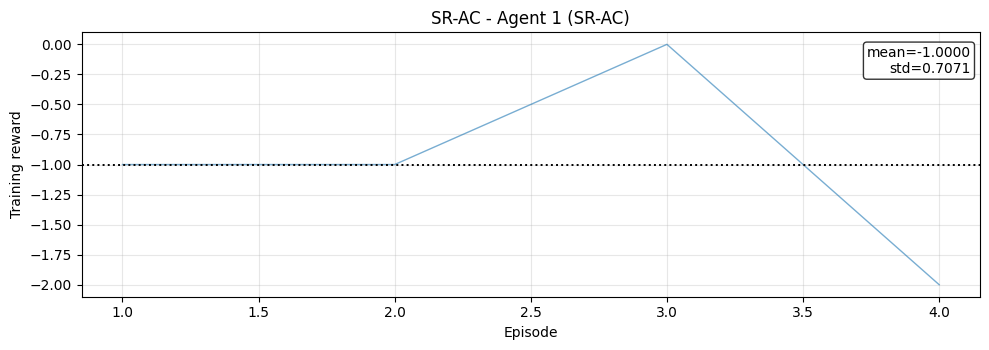

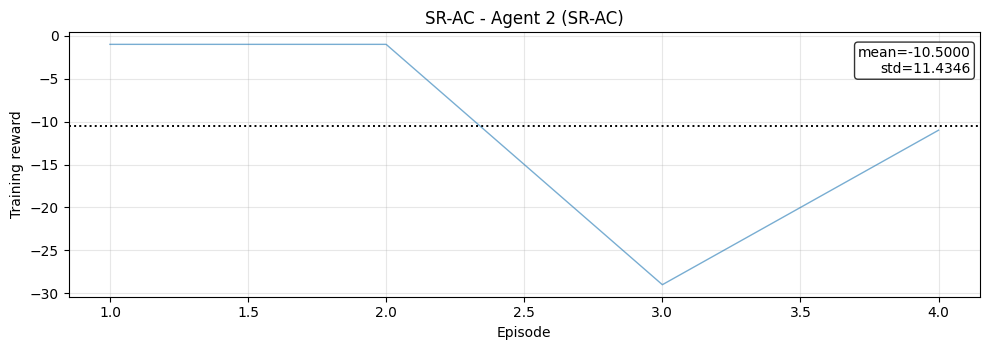

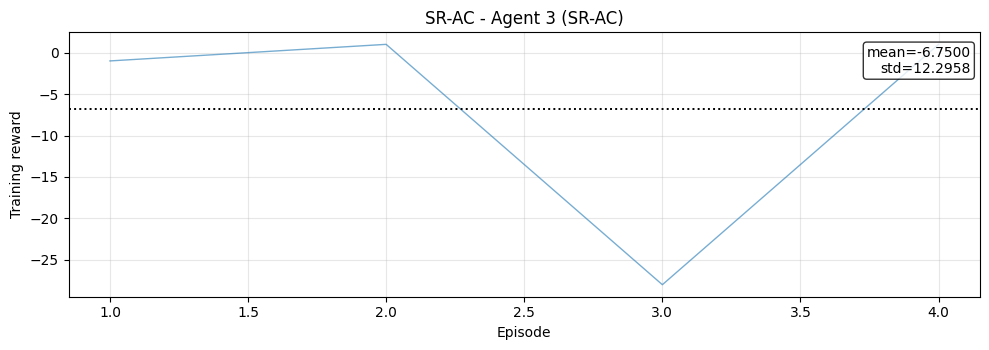

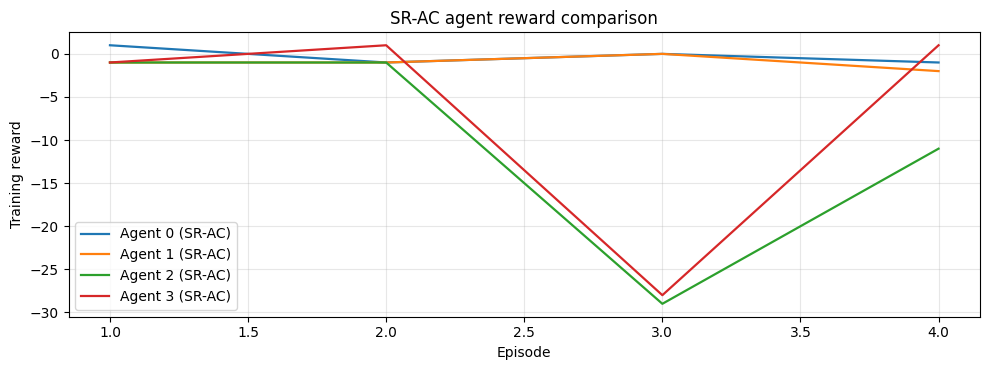

epsilon=1.0 schedule=constant decay_rate=0.995 artifact_dir=/home/wowthecoder/SRE-DQN/discrete_action_space/pommerman_ffa/srac/training/1.0/constant


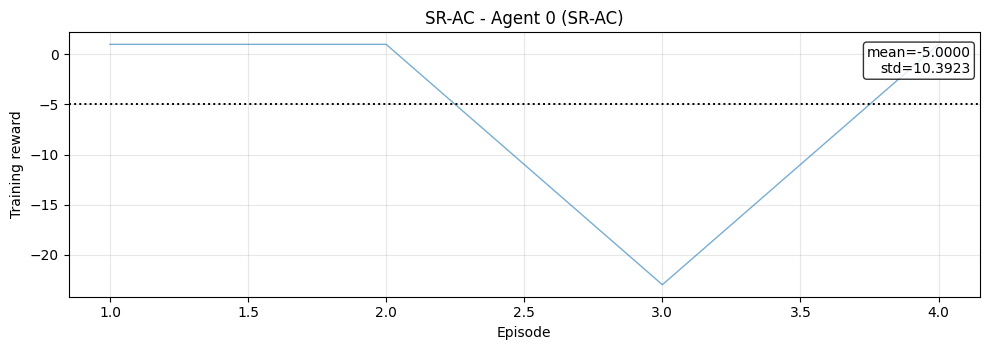

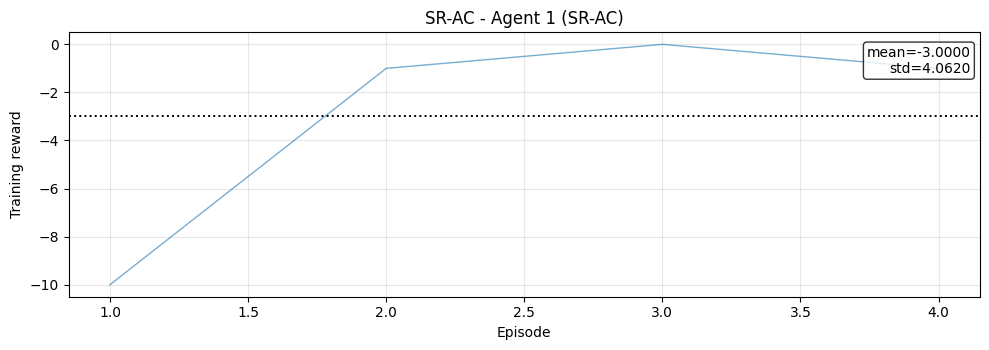

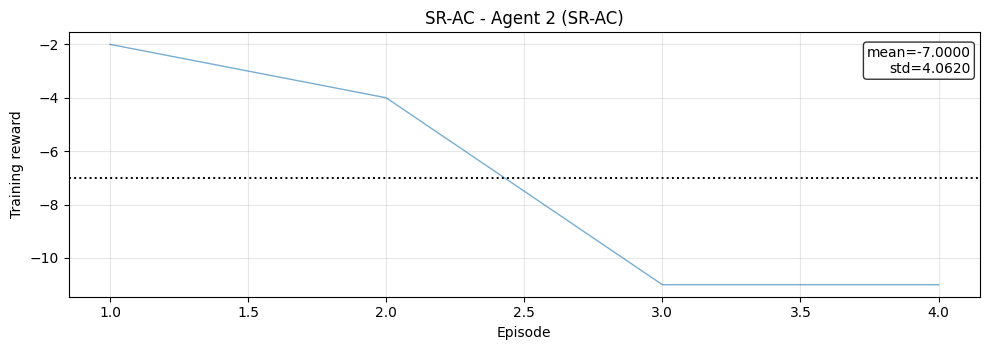

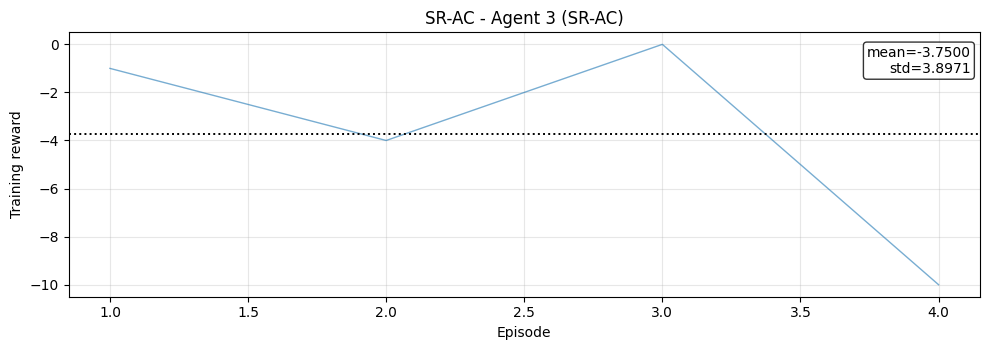

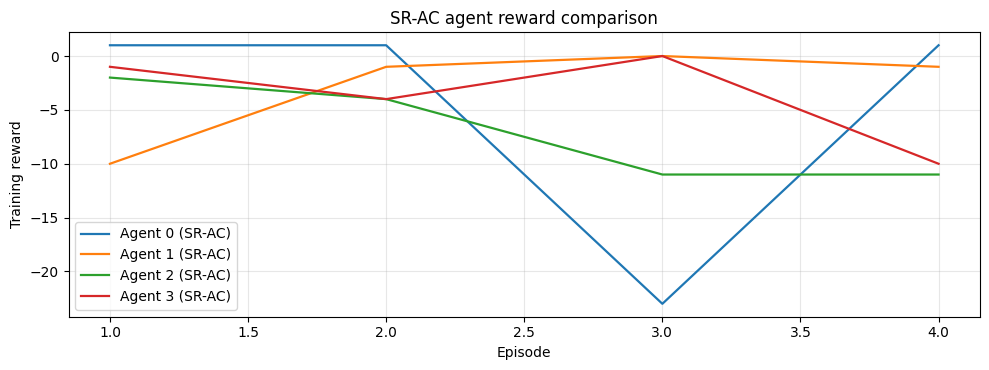

epsilon=1.0 schedule=exponential decay_rate=0.995 artifact_dir=/home/wowthecoder/SRE-DQN/discrete_action_space/pommerman_ffa/srac/training/1.0/exponential


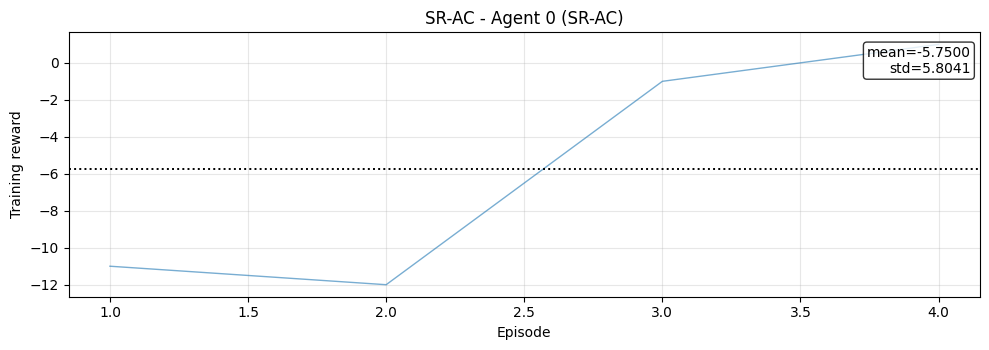

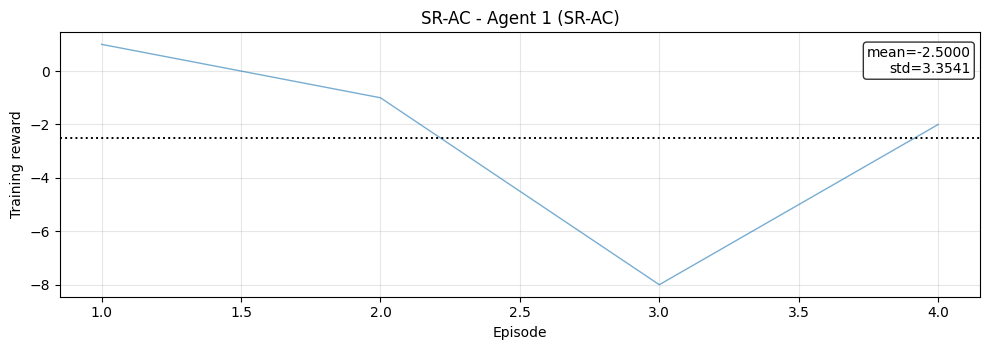

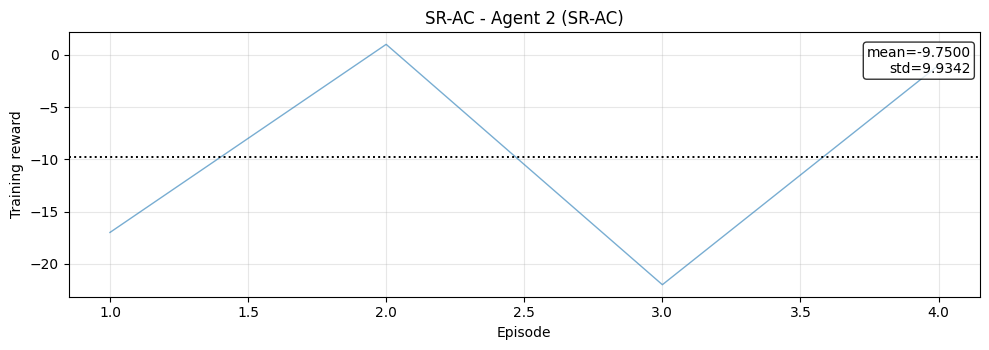

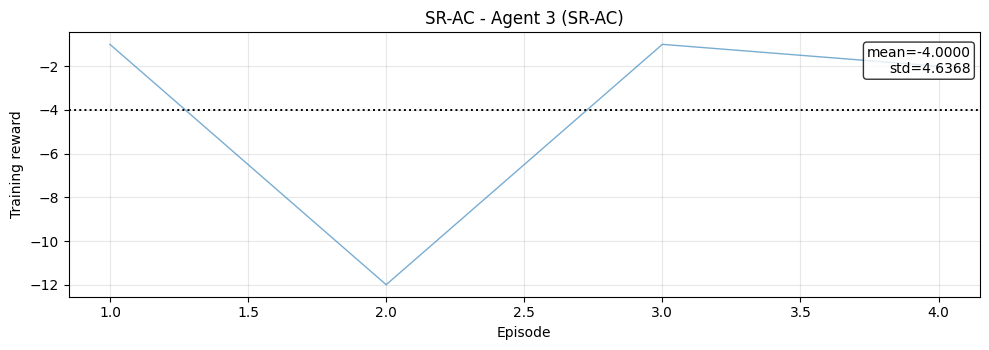

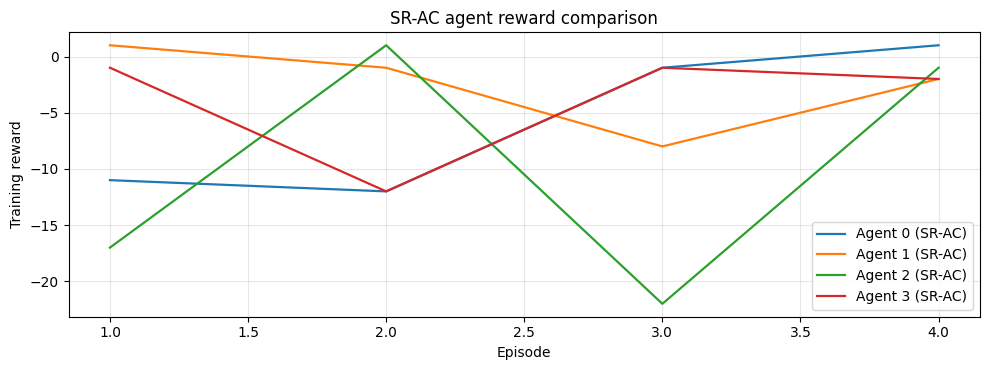

{'linear': {'environment': 'pommerman_ffa',
  'scenario_name': 'Pommerman FFA',
  'pair_label': 'SR-AC self-play',
  'pair_slug': 'sr_ac',
  'algorithm': 'SR-AC',
  'rewards': [[1.0, -1.0, 0.0, -1.0],
   [-1.0, -1.0, 0.0, -2.0],
   [-1.0, -1.0, -29.0, -11.0],
   [-1.0, 1.0, -28.0, 1.0]],
  'n_episodes': 4,
  'seed': 2125,
  'num_agents': 4,
  'num_actions': 6,
  'episode_lengths': [12, 12, 40, 21],
  'agent_labels': ['Agent 0 (SR-AC)',
   'Agent 1 (SR-AC)',
   'Agent 2 (SR-AC)',
   'Agent 3 (SR-AC)'],
  'artifact_dir': '/home/wowthecoder/SRE-DQN/discrete_action_space/pommerman_ffa/srac/training/1.0/linear',
  'solver_name': 'path_tvc_mcp_nplayer_pool',
  'nfg_transformer_checkpoint_path': None,
  'nfg_transformer_fallback_enabled': False,
  'nfg_transformer_accept_exploitability_tol': None,
  'epsilon_robust_initial': 1.0,
  'epsilon_schedule': 'linear',
  'robust_decay_rate': 0.995,
  'gradient_steps': 6,
  'batch_size': 32,
  'learning_starts': 64,
  'train_every': 4,
  'actor_update

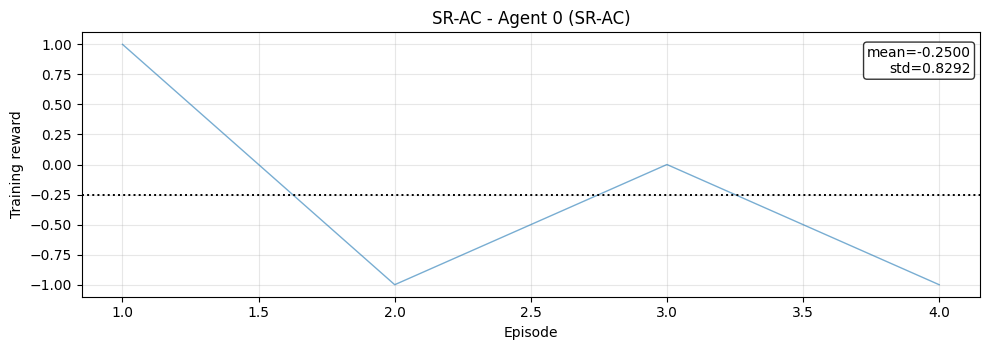

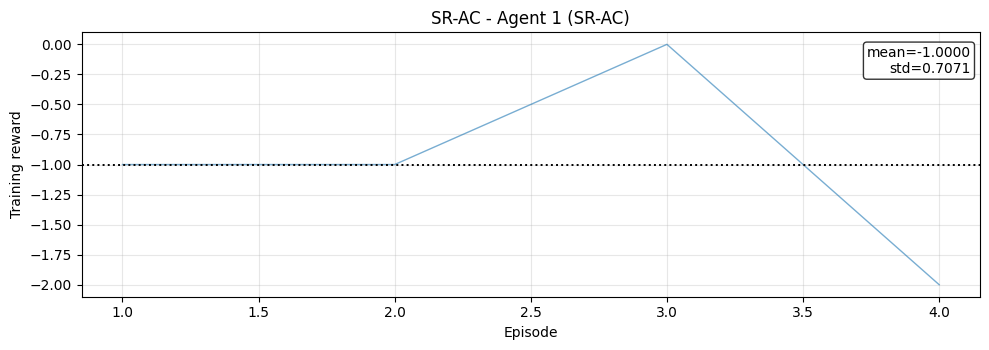

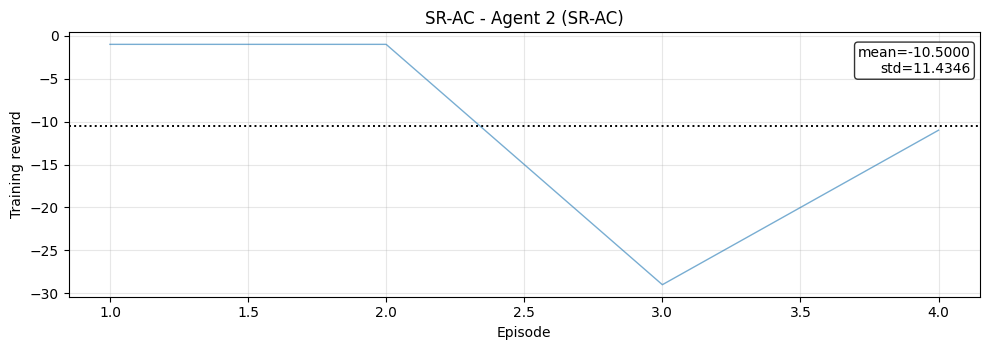

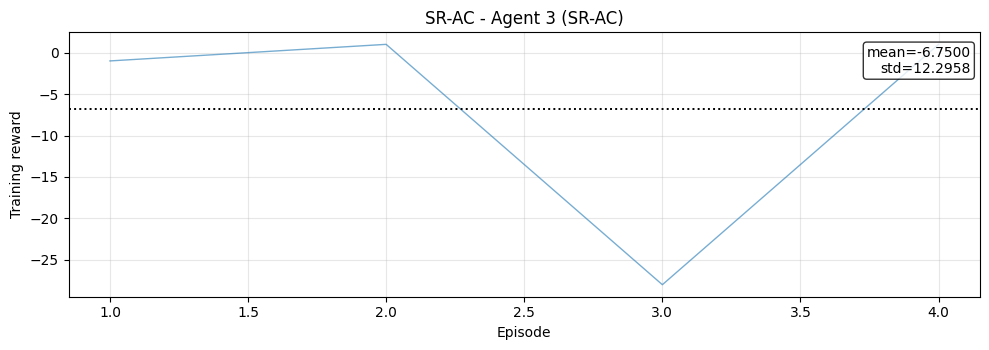

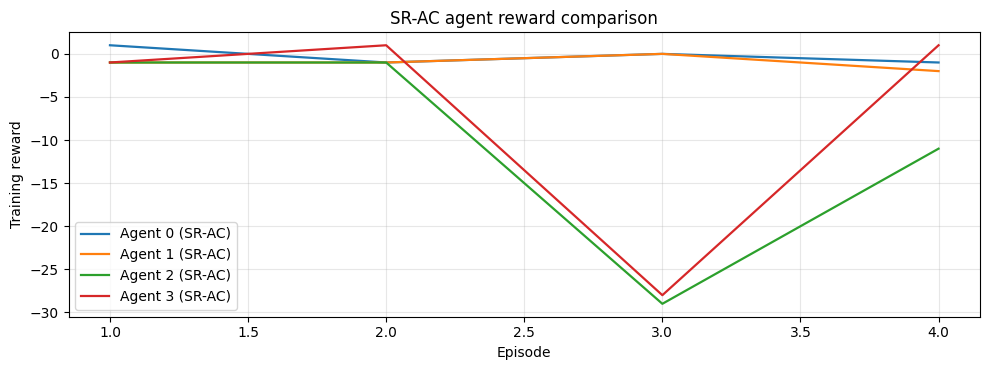

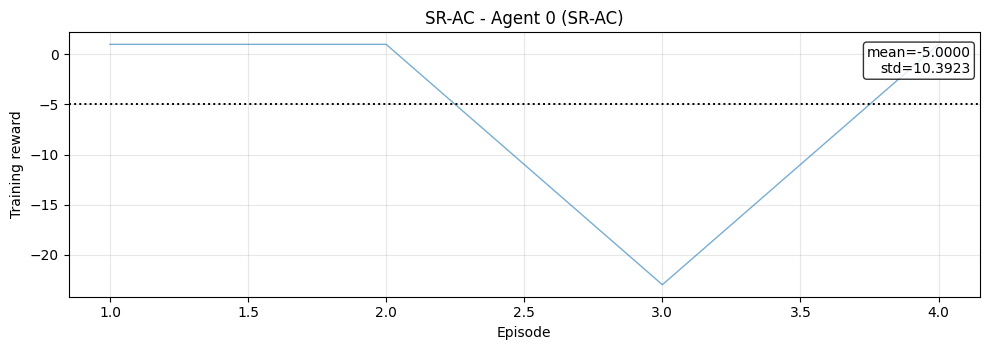

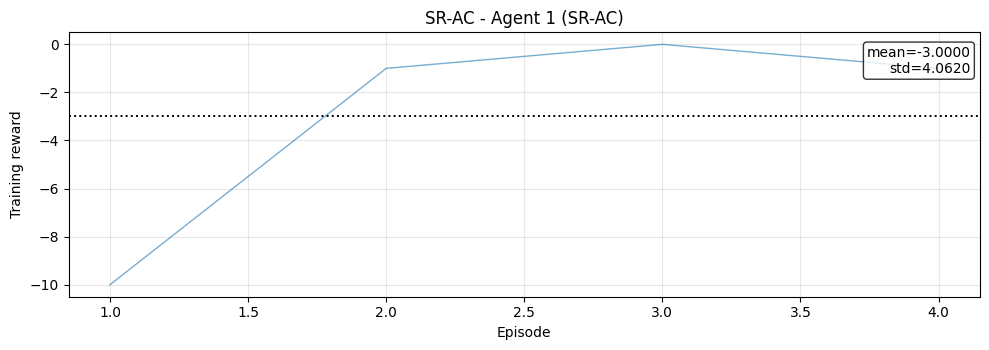

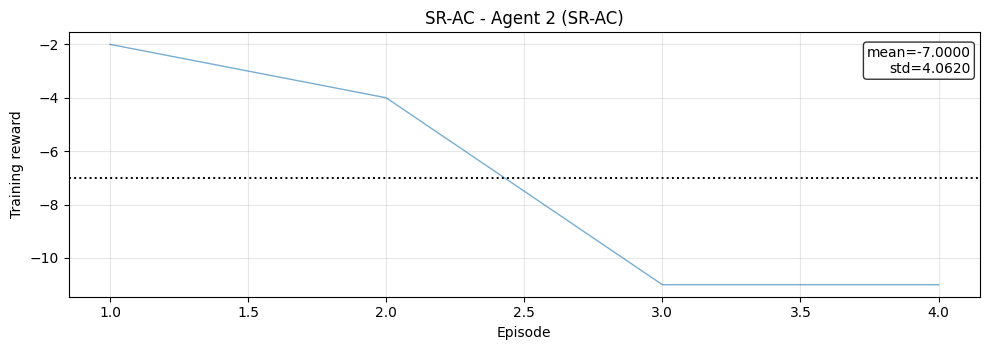

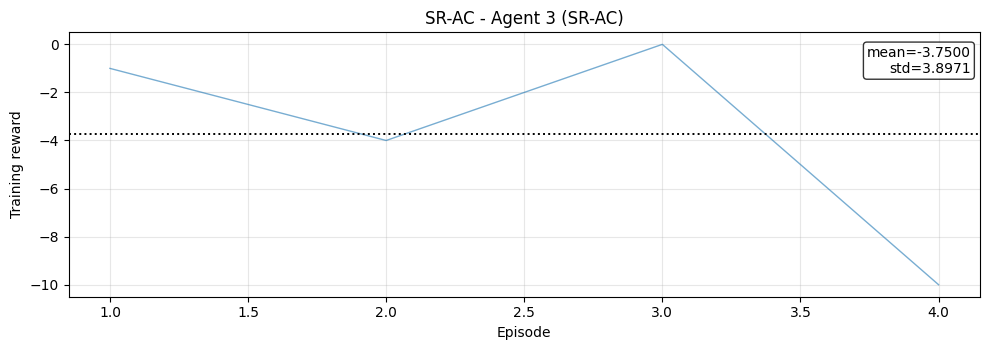

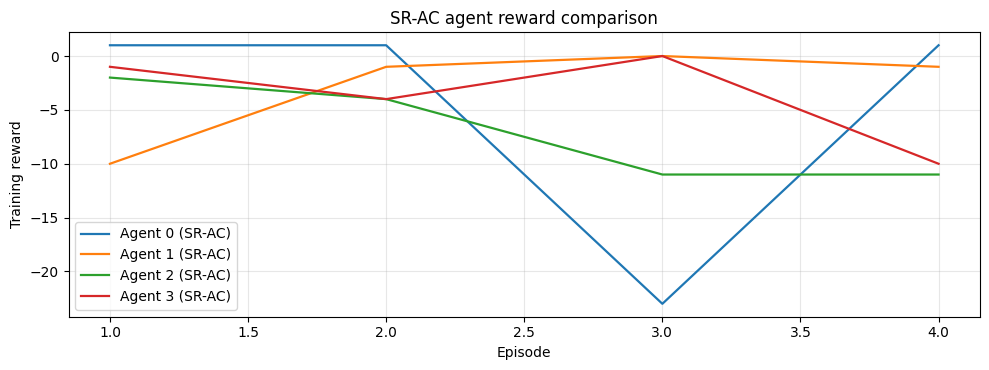

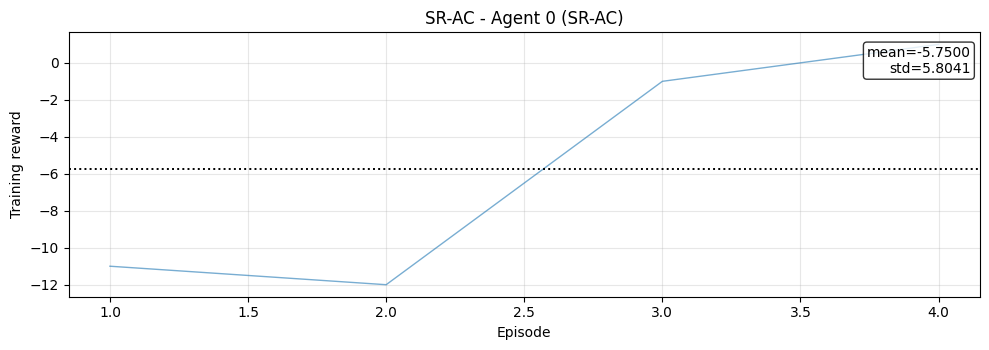

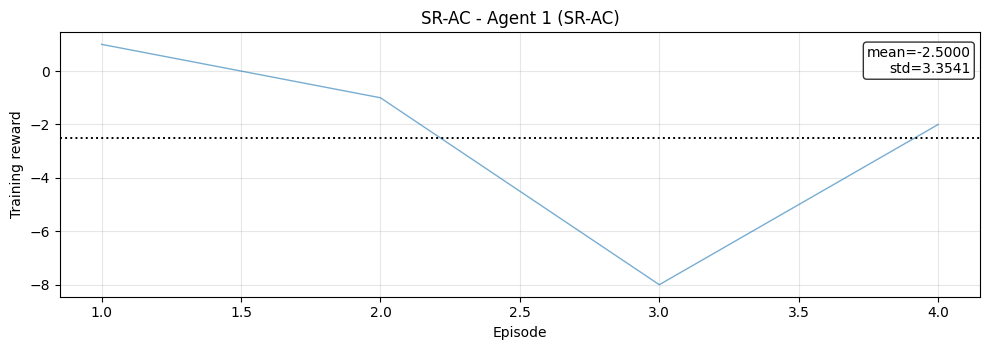

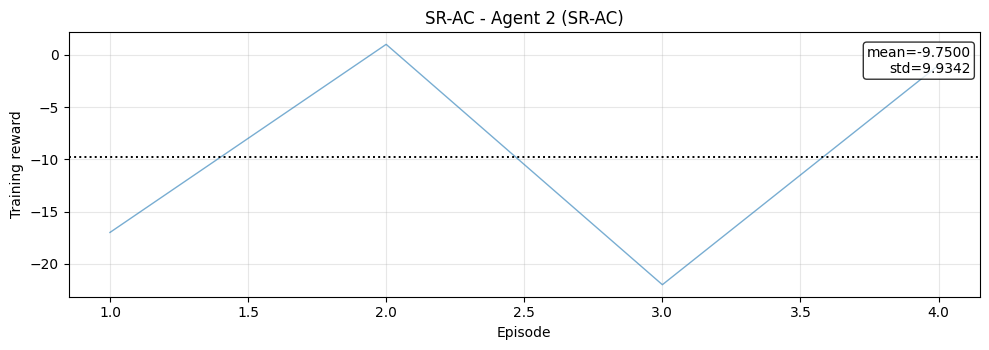

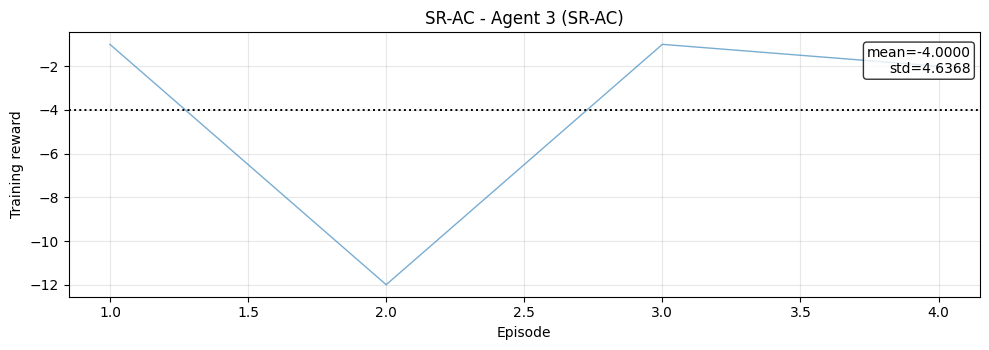

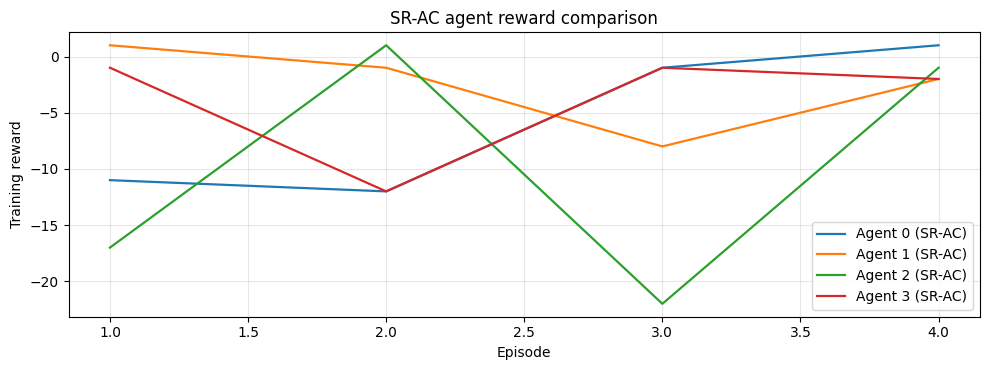

In [7]:
epsilon_1_0_stats = run_srac_schedule_sweep(1.0, seed_offset=100)
show_schedule_training_plots(1.0, epsilon_1_0_stats)

In [8]:
summary_rows = []
for epsilon, schedule_stats in srac_stats.items():
    for schedule, stats in schedule_stats.items():
        summary_rows.append(
            {
                "epsilon": epsilon,
                "schedule": schedule,
                "robust_decay_rate": stats.get("robust_decay_rate"),
                "best_joint_reward": stats.get("best_joint_reward"),
                "best_loss": stats.get("best_loss"),
                "latest_loss": stats.get("latest_loss"),
                "artifact_dir": stats.get("artifact_dir"),
            }
        )

summary_rows

[{'epsilon': 0.01,
  'schedule': 'linear',
  'robust_decay_rate': 0.995,
  'best_joint_reward': -10.0,
  'best_loss': 0.0706348568201065,
  'latest_loss': 0.0706348568201065,
  'artifact_dir': '/home/wowthecoder/SRE-DQN/discrete_action_space/pommerman_ffa/srac/training/0.01/linear'},
 {'epsilon': 0.01,
  'schedule': 'constant',
  'robust_decay_rate': 0.995,
  'best_joint_reward': -9.0,
  'best_loss': 0.13030022382736206,
  'latest_loss': 0.13030022382736206,
  'artifact_dir': '/home/wowthecoder/SRE-DQN/discrete_action_space/pommerman_ffa/srac/training/0.01/constant'},
 {'epsilon': 0.01,
  'schedule': 'exponential',
  'robust_decay_rate': 0.995,
  'best_joint_reward': -8.0,
  'best_loss': 0.040598802268505096,
  'latest_loss': 0.16881443560123444,
  'artifact_dir': '/home/wowthecoder/SRE-DQN/discrete_action_space/pommerman_ffa/srac/training/0.01/exponential'},
 {'epsilon': 0.1,
  'schedule': 'linear',
  'robust_decay_rate': 0.995,
  'best_joint_reward': -12.0,
  'best_loss': 0.069388598